In [3]:
import jax
import jax.numpy as jnp

def sample_actions(act_logits, random_key, task, batch_size=1):
    """
    act_logits:
       For "sampling": shape (parallel_env, 1, 2*action_dim)
       For "batch": same input shape; output will have an extra sample axis.
    random_key: jax PRNG key
    task: "sampling" or "batch"
    batch_size: number of samples per env (only used in "batch" branch)
    """
    if task == "batch":
        batch_size = 1  # number of samples per env
        action_dim = act_logits.shape[-1] // 2

        act_logits  = act_logits = jnp.repeat(act_logits, batch_size, axis=2)
        means = act_logits[..., :action_dim]
        log_stds = act_logits[..., action_dim:]
        log_stds = jnp.clip(log_stds, -20.0, 2.0)
        stds = jnp.exp(log_stds)
        # print("my ass", log_stds, means)
        # 4. Sample noise and compute actions:
        noise = jax.random.normal(random_key, shape=means.shape)  # shape: (parallel_env, batch_size, action_dim)
        # print("n", noise.shape, noise)
        acts_tick = means + noise * stds  # shape: (parallel_env, batch_size, action_dim)

    elif task == "sampling":
        action_dim = act_logits.shape[-1] // 2
        means = act_logits[..., :action_dim].squeeze(-1)
        log_stds = act_logits[..., action_dim:].squeeze(-1)
        # print("policy_out", act_logits.shape, "mean", means.shape, "std", log_stds.shape)
        
        # Clip log_stds for numerical stability
        log_stds = jnp.clip(log_stds, -20.0, 2.0)
        stds = jnp.exp(log_stds)
        # print("my pus", log_stds, means)
        # Sample from standard normal and scale
        noise = jax.random.normal(random_key, means.shape)
        # print("f", noise.shape, noise)
        acts_tick = means + noise * stds
        # print(acts_tick.shape)
        # jax.debug.print("dit kan echt niet meer {} {} {} ", means.shape, log_stds.shape, acts_tick.shape)
        acts_tick = jnp.squeeze(acts_tick)
        

    else:
        raise ValueError("Invalid task. Choose either 'batch' or 'sampling'.")
    return acts_tick

def gaussian_log_prob(actions, act_logits, task):
    print(act_logits.shape, actions.shape)
    """
    actions:
       For "sampling": shape (time, env_steps, action_dim)  (e.g., (1, 256, 1))
       For "batch": if actions lack a sample axis, one will be added.
    act_logits:
       For "sampling": shape (time, env_steps, 1, 2*action_dim)
       For "batch": same expected shape.
    Returns:
       Gaussian log-probabilities. For "batch" mode, the log-probabilities are computed per sample
       (optionally summed over the action dimension).
    """
    if task == "sampling":
        action_dim = act_logits.shape[-1] // 2
        means = act_logits[..., :action_dim].squeeze()
        log_stds = act_logits[..., action_dim:].squeeze()
        
        
        # Clip log_stds for numerical stability
        log_stds = jnp.clip(log_stds, -20.0, 2.0)
        
        
        variance = jnp.exp(2 * log_stds)
        # print("variance", variance, "means", means, "log_stds", log_stds)
        
        log_prob = -0.5 * (
            jnp.log(2 * jnp.pi)
            + 2 * log_stds
            + (actions - means) ** 2 / variance
                    )

    elif task == "batch":
        action_dim = act_logits.shape[-1] // 2
        batch_size = 1
        act_logits = jnp.broadcast_to(act_logits, (act_logits.shape[0], act_logits.shape[1], batch_size, act_logits.shape[2]))
        act_logits = jnp.repeat(act_logits, batch_size, axis=2)
        means = act_logits[..., :action_dim]
        log_stds = act_logits[..., action_dim:]
        
        
    
        log_stds = jnp.clip(log_stds, -20.0, 2.0)
        variance = jnp.exp(2 * log_stds)
        # print("variance", variance, "means", means, "log_stds", log_stds)
        
        log_prob = -0.5 * (jnp.log(2 * jnp.pi) + 2 * log_stds + ((actions - means) ** 2) / variance)
        log_prob = jnp.squeeze(log_prob.sum(axis=2), axis=-1)

    else:
        raise ValueError("Invalid task. Choose either 'batch' or 'sampling'.")
    return log_prob




In [4]:
# -------------------------------
# Testing the functionality

key = jax.random.PRNGKey(0)

# print("=== Testing sample_actions ===")
# # For "sampling" branch:
# # Input: (parallel_env, 1, 2*action_dim) e.g. (8, 1, 2) with action_dim=1.
# # act_logits_sampling = jax.random.normal(key, shape=(8, 1, 2))
# act_logits_sampling = jax.numpy.ones((8, 1, 2))
# print("act_logits_sampling", act_logits_sampling.shape)
# # key, subkey = jax.random.split(key)
# sampled_sampling = sample_actions(act_logits_sampling, key, task="sampling")
# # print("Sampling branch output (should be shape (8,) or (8,1) after squeezing):", sampled_sampling.shape)
# # print("Sampling branch output:", sampled_sampling)

# # For "batch" branch with batch_size = 1:
# # key, subkey = jax.random.split(key)
# sampled_batch = sample_actions(act_logits_sampling, key, task="batch", batch_size=1)
# # Remove singleton sample dimension for comparison:
# # sampled_batch_squeezed = jnp.squeeze(sampled_batch)
# # print("Batch branch (batch_size=1) output (after squeezing, should be same as sampling):", sampled_batch_squeezed.shape)
# # print("Batch branch output:", sampled_batch_squeezed)
# print(sampled_sampling, "\n", sampled_batch)

print("\n=== Testing gaussian_log_prob ===")
# For "sampling" branch log_prob:
# Let act_logits have shape (time, env_steps, 1, 2*action_dim), e.g. (1, 256, 1, 2)
# And actions shape (1, env_steps, 1), e.g. (1, 256, 1)
env_steps = 8
# act_logits_log_prob = jax.random.normal(key, shape=(1, env_steps, 1, 2))
# actions_log_prob = jax.random.normal(key, shape=(1, env_steps))
act_logits_log_prob = jax.numpy.ones((1, env_steps, 2))
actions_log_prob = jax.numpy.ones((1, env_steps))
log_prob_sampling = gaussian_log_prob(actions_log_prob, act_logits_log_prob, task="sampling")
print("Gaussian log-prob (sampling) output shape:", log_prob_sampling)

# For "batch" branch log_prob:
act_logits_log_prob = jax.numpy.ones((1, env_steps, 1, 2))
actions_log_prob = jax.numpy.ones((1, env_steps, 1, 1))
act_logits_log_prob = jax.random.normal(key, shape=(1, env_steps, 1, 2))
actions_log_prob = jax.random.normal(key, shape=(1, env_steps, 1, 1))
log_prob_batch = gaussian_log_prob(actions_log_prob, act_logits_log_prob, task="batch")
print("Gaussian log-prob (batch) output shape:", log_prob_batch)

# Optionally, if you want to aggregate the samples (e.g., by summing over the sample axis),
# you could do:
# if log_prob_batch.ndim > 3:  # if sample axis exists
#     log_prob_batch_aggregated = log_prob_batch.sum(axis=2)
#     print("Gaussian log-prob (batch) aggregated over samples shape:", log_prob_batch_aggregated.shape)


=== Testing gaussian_log_prob ===
(1, 8, 2) (1, 8)
Gaussian log-prob (sampling) output shape: [[-1.9189385 -1.9189385 -1.9189385 -1.9189385 -1.9189385 -1.9189385
  -1.9189385 -1.9189385]]
(1, 8, 1, 2) (1, 8, 1, 1)


ValueError: Incompatible shapes for broadcasting: (1, 8, 1, 2) and requested shape (1, 8, 1, 1)

In [ ]:
import jax.numpy as jnp
import numpy as np

# Example array of shape (1, 256, 1, 2)
array = np.random.rand(1, 2, 1, 2)  # Replace with your actual array
print(array)
# Desired expansion factor for the 3rd dimension (e.g., x = 4)
x = 4  

# Expand along the third axis
expanded_array = np.tile(array, (1, 1, x, 1))
a = np.repeat(array, x, axis=2)
print(a)
print(expanded_array.shape)  # Should output (1, 256, x, 2)

print(array,"\n", expanded_array)


[[[[0.7275847  0.898863  ]]

  [[0.26442263 0.96225166]]]]
[[[[0.7275847  0.898863  ]
   [0.7275847  0.898863  ]
   [0.7275847  0.898863  ]
   [0.7275847  0.898863  ]]

  [[0.26442263 0.96225166]
   [0.26442263 0.96225166]
   [0.26442263 0.96225166]
   [0.26442263 0.96225166]]]]
(1, 2, 4, 2)
[[[[0.7275847  0.898863  ]]

  [[0.26442263 0.96225166]]]] 
 [[[[0.7275847  0.898863  ]
   [0.7275847  0.898863  ]
   [0.7275847  0.898863  ]
   [0.7275847  0.898863  ]]

  [[0.26442263 0.96225166]
   [0.26442263 0.96225166]
   [0.26442263 0.96225166]
   [0.26442263 0.96225166]]]]


In [ ]:
import numpy as np

class PolynomialFunction:
    def __init__(self, action_dim, degree, x_range):
        self.action_dim = action_dim
        self.degree = degree
        self.x_range = x_range
        self.shift_polynomial()

    def shift_polynomial(self):
        # Randomize the maximum location uniformly for each dimension.
        self.x_max = np.random.uniform(self.x_range[0], self.x_range[1], size=())
        # Randomize the constant such that f(x_max) = c, and weights.
        self.c = np.random.uniform(5.0, 20.0)
        self.weights = np.random.uniform(0.5, 2.0, size=(self.action_dim,))

    def compute_y(self, x):
        """
        Compute the polynomial value for a batch of inputs:
            f(x) = c - sum_{i=1}^{action_dim} (w_i * (x_i - x_max_i)**degree)
            
        Supports inputs of shape `(batch_size, action_dim)`.
        If `x` is `(action_dim,)`, it is treated as `(1, action_dim)`.
        """
        x = np.atleast_2d(x)  # Ensure x is (batch_size, action_dim)
        
        # Compute difference
        diff = x - self.x_max  # Shape: (batch_size, action_dim)
        print("x", x, " - ", self.x_max, " = ", diff)
        
        # Compute weighted polynomial term
        weighted_term = self.weights * (diff ** self.degree)  # Shape: (batch_size, action_dim)
        
        # Sum across action_dim to get final output
        result = self.c - np.sum(weighted_term, axis=1)  # Shape: (batch_size,)
        
        return result.squeeze()  # Convert (1,) to scalar if needed


poly_fn = PolynomialFunction(action_dim=3, degree=2, x_range=(-5, 5))

x_single = np.array([1.0, 2.0, 3.0])
y_single = poly_fn.compute_y(x_single)
print("Single input y:", y_single)

x_batch = np.array([[1.0, 2.0, 3.0], [0.5, 1.5, 2.5], [1.0, 2.0, 3.0]])
y_batch = poly_fn.compute_y(x_batch)
print("Batch input y:", y_batch)

x [[1. 2. 3.]]  -  -2.2850726594570894  =  [[3.28507266 4.28507266 5.28507266]]
Single input y: -72.21117464033254
x [[1.  2.  3. ]
 [0.5 1.5 2.5]
 [1.  2.  3. ]]  -  -2.2850726594570894  =  [[3.28507266 4.28507266 5.28507266]
 [2.78507266 3.78507266 4.78507266]
 [3.28507266 4.28507266 5.28507266]]
Batch input y: [-72.21117464 -54.51128128 -72.21117464]


In [ ]:
import jax
import jaxlib
import jax.numpy as jnp

jax.scipy.stats.norm.logpdf(jnp.array([[2.0, 2.0, 3.0], [4.0, 2.0, 3.0]]), jnp.array([[2.0, 1.0, 3.0], [4.0, 2.0, 3.0]]))

noise = jax.random.normal(key, shape=(2, 3))
print

Array([[-0.9189385, -1.4189385, -0.9189385],
       [-0.9189385, -0.9189385, -0.9189385]], dtype=float32)

In [ ]:
import jax
import jax.numpy as jnp
export CUDA_VISIBLE_DEVICES=0

print("JAX Devices:", jax.devices())

x = jnp.ones((1000, 1000))
print("Device for computation:", x.device())

JAX Devices: [CpuDevice(id=0)]


TypeError: 'Device' object is not callable

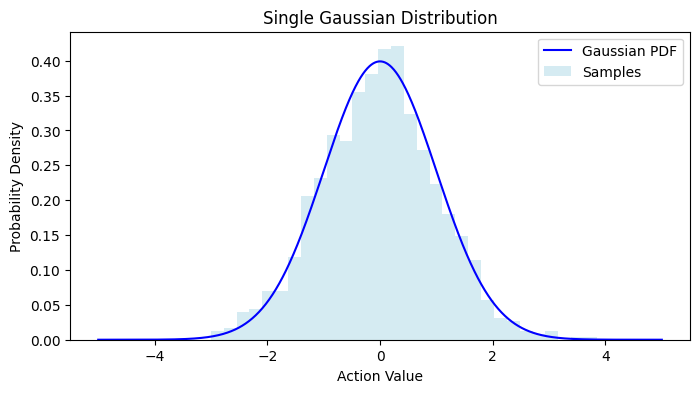

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters for the Gaussian
mu = 0.0
sigma = 1.0

# Domain for plotting the PDF
x = np.linspace(-5, 5, 1000)
pdf = norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(8, 4))
plt.plot(x, pdf, 'b-', label='Gaussian PDF')
# Sample points from the Gaussian
samples = np.random.normal(mu, sigma, size=1000)
plt.hist(samples, bins=30, density=True, alpha=0.5, color='lightblue', label='Samples')
plt.title('Single Gaussian Distribution')
plt.xlabel('Action Value')
plt.ylabel('Probability Density')
plt.legend()
plt.show()


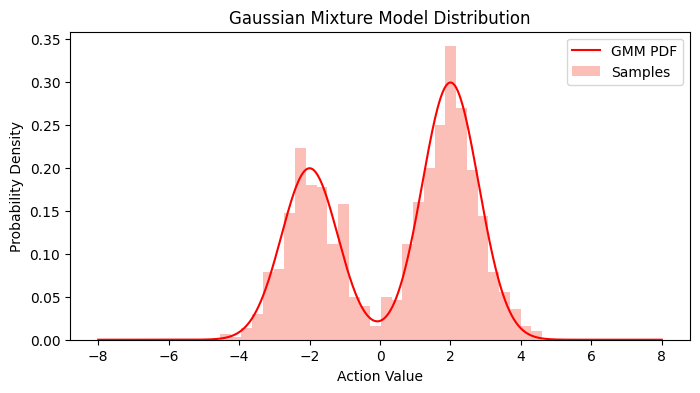

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define parameters for two components
mu1, sigma1, w1 = -2, 0.8, 0.4
mu2, sigma2, w2 =  2, 0.8, 0.6

# Domain for plotting the PDF
x = np.linspace(-8, 8, 1000)
pdf = w1 * norm.pdf(x, loc=mu1, scale=sigma1) + w2 * norm.pdf(x, loc=mu2, scale=sigma2)

plt.figure(figsize=(8, 4))
plt.plot(x, pdf, 'r-', label='GMM PDF')

# Sample points from the GMM:
samples = []
for _ in range(1000):
    if np.random.rand() < w1:
        samples.append(np.random.normal(mu1, sigma1))
    else:
        samples.append(np.random.normal(mu2, sigma2))

plt.hist(samples, bins=30, density=True, alpha=0.5, color='salmon', label='Samples')
plt.title('Gaussian Mixture Model Distribution')
plt.xlabel('Action Value')
plt.ylabel('Probability Density')
plt.legend()
plt.show()


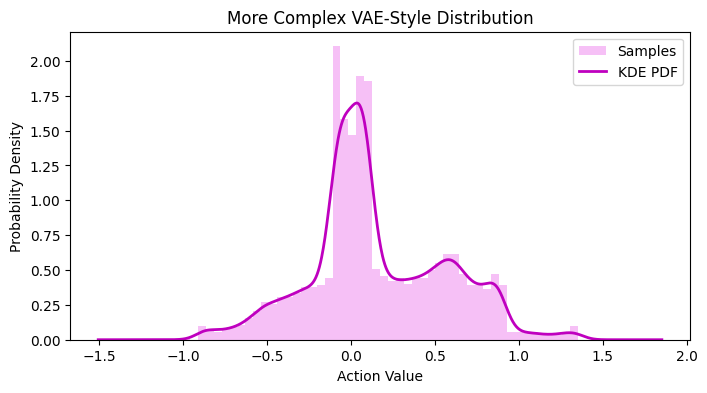

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 1) Define a mixture distribution for the latent variable z
#    This mixture has two components, each a Gaussian.
def sample_z(n):
    z_samples = []
    p = 0.4  # mixing weight for the first component
    for _ in range(n):
        if np.random.rand() < p:
            # Sample from N(-2, 0.5^2)
            z_samples.append(np.random.normal(-2.0, 0.5))
        else:
            # Sample from N(2, 1.0^2)
            z_samples.append(np.random.normal(2.0, 1.0))
    return np.array(z_samples)

# 2) Define a more complex decoder function
#    Feel free to adjust this to get different shapes.
def decoder(z):
    # Non-linear combination of sin, cos, polynomials, etc.
    return 0.5 * np.sin(2.0 * z) + 0.3 * np.sin(3.0 * z) + 0.2 * z

# 3) Sample from the "VAE" by:
#    - drawing latent z from a mixture
#    - mapping z -> action a via the decoder
num_samples = 20000
z_samples = sample_z(num_samples)
a_samples = decoder(z_samples)

# 4) Use kernel density estimation (KDE) to approximate the PDF of a
density = gaussian_kde(a_samples, bw_method='scott')  
#   - "bw_method" controls the bandwidth. 'scott' or 'silverman' often work well.

# 5) Create a grid for plotting the PDF
xmin, xmax = min(a_samples), max(a_samples)
xrange = np.linspace(xmin - 0.5, xmax + 0.5, 1000)
pdf_est = density(xrange)

# 6) Plot histogram + estimated PDF
plt.figure(figsize=(8, 4))
plt.hist(a_samples, bins=50, density=True, alpha=0.5, color='violet', label='Samples')
plt.plot(xrange, pdf_est, 'm-', linewidth=2, label='KDE PDF')
plt.title('More Complex VAE-Style Distribution')
plt.xlabel('Action Value')
plt.ylabel('Probability Density')
plt.legend()
plt.show()


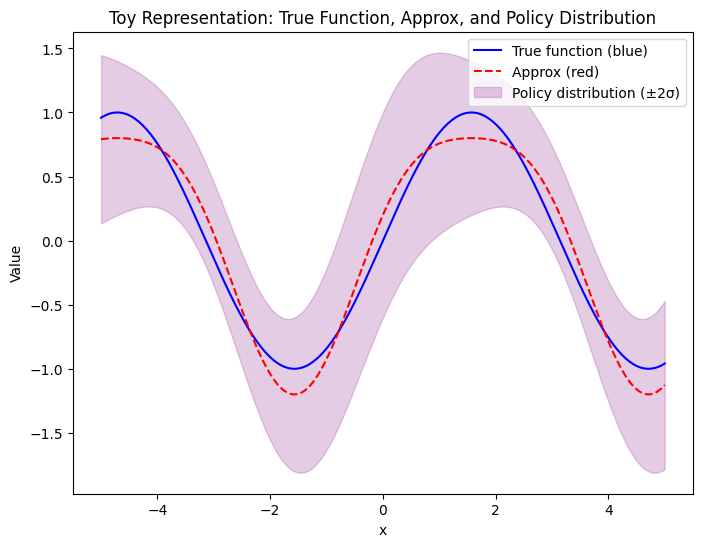

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1) "True" function (just for illustration)
def f_true(x):
    return np.sin(x)

# 2) "Nonlinear approximation" (like your LSTM-based net output)
def f_approx(x):
    return np.sin(x) + 0.2*np.cos(2*x)

# 3) A toy standard deviation function for the policy distribution
#    In reality, your policy net might output a log-variance or mixture weights, etc.
def policy_std(x):
    return 0.3 + 0.1*np.cos(x)

# Create a domain for x
x = np.linspace(-5, 5, 300)
y_true = f_true(x)
y_approx = f_approx(x)
std = policy_std(x)  # for the single-Gaussian policy

# Plot
plt.figure(figsize=(8, 6))

# (A) True function in blue
plt.plot(x, y_true, 'b-', label='True function (blue)')

# (B) Nonlinear approximation in red
plt.plot(x, y_approx, 'r--', label='Approx (red)')

# (C) Policy distribution in purple (±2 std around the approx)
plt.fill_between(x,
                 y_approx - 2*std,
                 y_approx + 2*std,
                 color='purple', alpha=0.2,
                 label='Policy distribution (±2σ)')

plt.title("Toy Representation: True Function, Approx, and Policy Distribution")
plt.xlabel("x")
plt.ylabel("Value")
plt.legend()
plt.show()


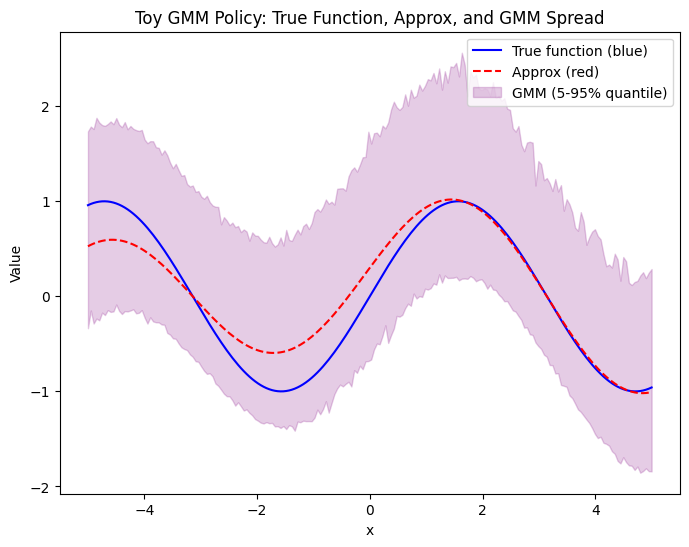

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Toy "true" function
def f_true(x):
    return np.sin(x)

# Toy "approx" function
def f_approx(x):
    return 0.8*np.sin(x) + 0.3*np.cos(0.5*x)

# For a GMM with 2 components at each x:
#   p(a | x) = w1(x)*N(mu1(x), std1(x)^2) + w2(x)*N(mu2(x), std2(x)^2)
# We'll define them just for illustration:
def gmm_params(x):
    # mixing weight
    w1 = 0.4 + 0.3*np.sin(0.2*x)
    w1 = (w1+1)/2  # shift to [0,1] range
    w2 = 1 - w1
    # means
    mu1 = f_approx(x) - 0.5
    mu2 = f_approx(x) + 1.0
    # std dev
    std1 = 0.2 + 0.1*np.cos(x)
    std2 = 0.3 + 0.15*np.sin(0.5*x)
    return w1, w2, mu1, mu2, std1, std2

# Let's do a quantile-based shading to show the "spread" of the GMM
def gmm_sample_quantiles(x, n_samples=200):
    # For each x, sample from the GMM many times, compute quantiles
    from numpy.random import randn, rand
    qs_5 = []
    qs_95 = []
    for xi in x:
        w1, w2, mu1, mu2, s1, s2 = gmm_params(xi)
        samples = []
        for _ in range(n_samples):
            if np.random.rand() < w1:
                samples.append(np.random.normal(mu1, s1))
            else:
                samples.append(np.random.normal(mu2, s2))
        samples = np.array(samples)
        qs_5.append(np.percentile(samples, 5))
        qs_95.append(np.percentile(samples, 95))
    return np.array(qs_5), np.array(qs_95)

# Main plotting
x = np.linspace(-5, 5, 200)
y_true = f_true(x)

qs_5, qs_95 = gmm_sample_quantiles(x)

plt.figure(figsize=(8, 6))
plt.plot(x, y_true, 'b-', label='True function (blue)')
plt.plot(x, f_approx(x), 'r--', label='Approx (red)')

# Purple shading from 5th to 95th percentile of the GMM
plt.fill_between(x, qs_5, qs_95, color='purple', alpha=0.2, label='GMM (5-95% quantile)')

plt.title("Toy GMM Policy: True Function, Approx, and GMM Spread")
plt.xlabel("x")
plt.ylabel("Value")
plt.legend()
plt.show()


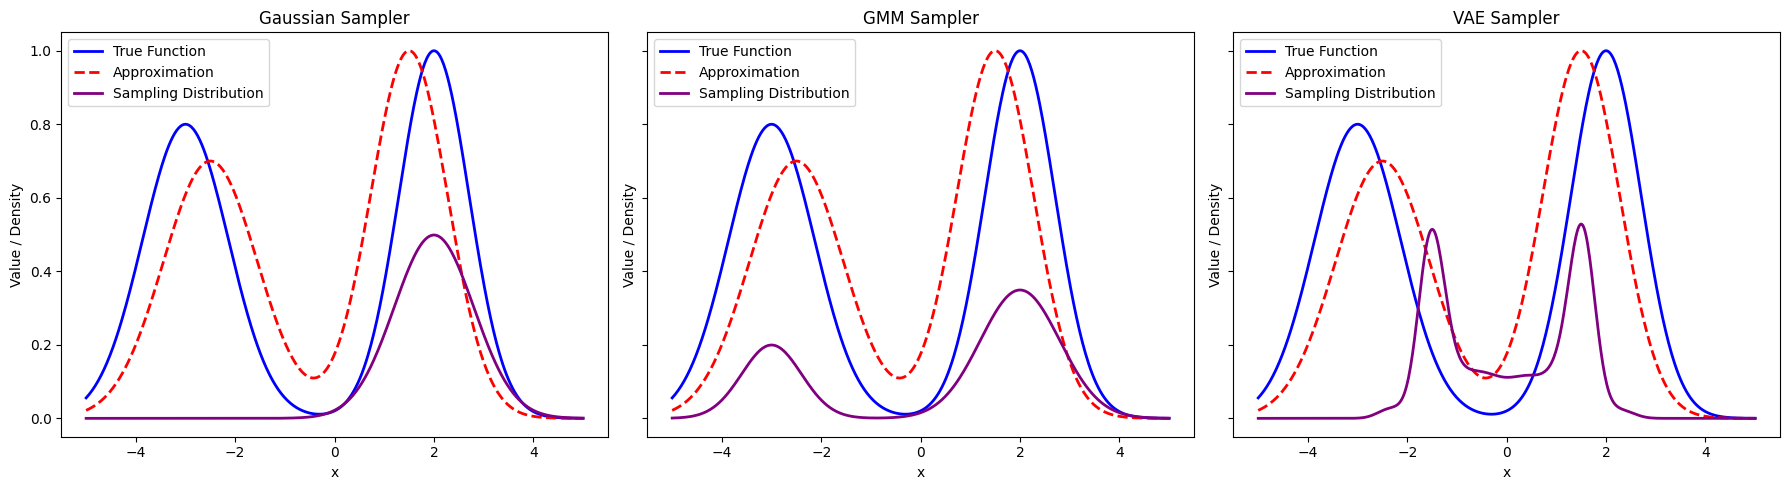

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

# Define the domain (e.g., action space)
x = np.linspace(-5, 5, 500)

# --------------------------------------------------------------------
# 1. Define a "True" function (blue) with two peaks.
def f_true(x):
    # Two peaks: one strong peak near x=2, and a smaller one near x=-3.
    return np.exp(-((x-2)**2)/1.0) + 0.8*np.exp(-((x+3)**2)/1.5)

# 2. Define an approximation function (red)
def f_approx(x):
    # A slightly shifted and smoothed version of f_true.
    return np.exp(-((x-1.5)**2)/1.2) + 0.7*np.exp(-((x+2.5)**2)/1.8)

# --------------------------------------------------------------------
# 3a. Gaussian sampler: A unimodal Gaussian centered at the high peak.
# For illustration, we assume the policy produces a Gaussian
# around the best (highest) region of f_true.
gaussian_pdf = norm.pdf(x, loc=2, scale=0.8)
# Normalize over our domain:
gaussian_pdf = gaussian_pdf / np.trapz(gaussian_pdf, x)

# --------------------------------------------------------------------
# 3b. GMM sampler: A mixture of two Gaussians, one for each peak.
# Here we weight the peak near x=-3 less than the one near x=2.
gmm_pdf = 0.3 * norm.pdf(x, loc=-3, scale=0.6) + 0.7 * norm.pdf(x, loc=2, scale=0.8)
gmm_pdf = gmm_pdf / np.trapz(gmm_pdf, x)

# --------------------------------------------------------------------
# 3c. VAE sampler: A non-linear, non-Gaussian shaped distribution.
# We simulate this by transforming a latent variable z via a non-linear function.
def vae_transform(z):
    # A non-linear decoder mapping from latent space z to x.
    return 2 * np.tanh(z) + 0.5 * np.sin(3 * z)

# Sample latent variable z from a standard normal.
z_samples = np.random.randn(10000)
# Map z to x using the decoder.
x_samples_vae = vae_transform(z_samples)
# Estimate the resulting density via kernel density estimation.
kde = gaussian_kde(x_samples_vae)
vae_pdf = kde(x)
# Normalize the KDE (should be near 1, but we enforce it).
vae_pdf = vae_pdf / np.trapz(vae_pdf, x)

# --------------------------------------------------------------------
# Plotting: Create one row with three subplots (one per sampler)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
titles = ['Gaussian Sampler', 'GMM Sampler', 'VAE Sampler']
sampler_pdfs = [gaussian_pdf, gmm_pdf, vae_pdf]

for ax, sampler_pdf, title in zip(axes, sampler_pdfs, titles):
    # Plot the "true" function (blue)
    ax.plot(x, f_true(x), 'b-', lw=2, label='True Function')
    # Plot the nonlinear approximation (red)
    ax.plot(x, f_approx(x), 'r--', lw=2, label='Approximation')
    # Plot the sampling distribution (purple)
    ax.plot(x, sampler_pdf, color='purple', lw=2, label='Sampling Distribution')
    
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('Value / Density')
    ax.legend()

plt.tight_layout()
plt.show()


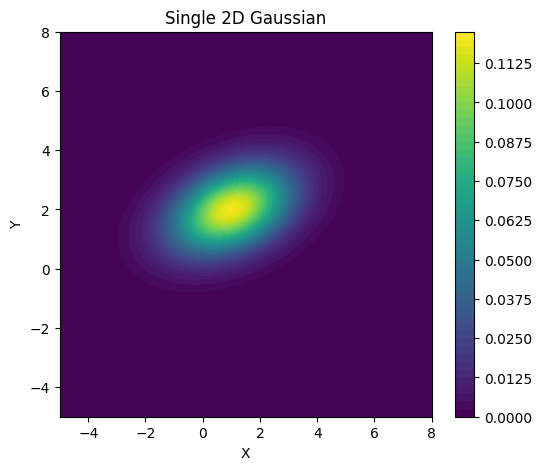

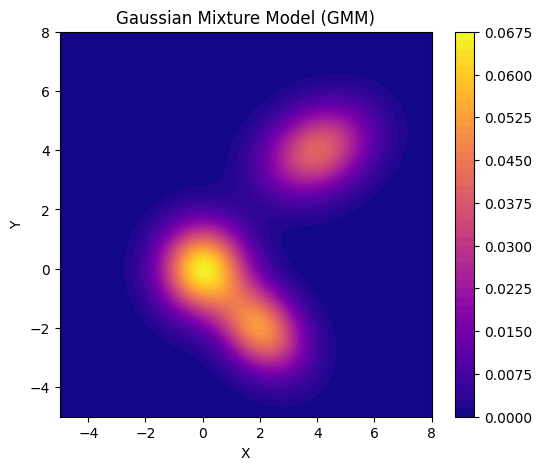

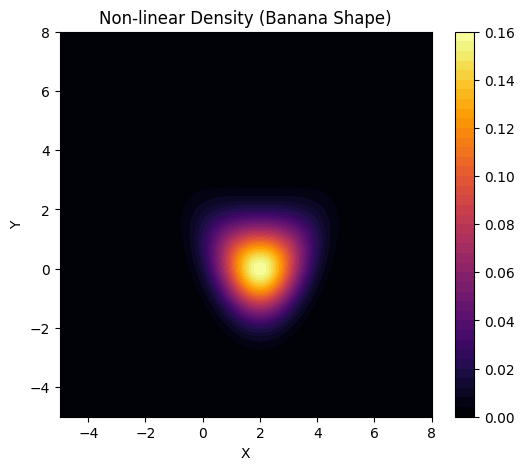

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create a 2D grid for plotting
x = np.linspace(-5, 8, 300)
y = np.linspace(-5, 8, 300)
X, Y = np.meshgrid(x, y)

def gaussian_density(x, y, mu, Sigma):
    """
    Computes the density of a 2D Gaussian.
    Parameters:
      x, y : grid arrays
      mu   : mean vector [mu_x, mu_y]
      Sigma: 2x2 covariance matrix
    Returns:
      Density evaluated over the grid.
    """
    det = np.linalg.det(Sigma)
    inv_Sigma = np.linalg.inv(Sigma)
    diff = np.stack([x - mu[0], y - mu[1]], axis=-1)
    exponent = -0.5 * np.sum(diff @ inv_Sigma * diff, axis=-1)
    return (1.0 / (2 * np.pi * np.sqrt(det))) * np.exp(exponent)

####################################
# Variation 1: Single 2D Gaussian
####################################
mu_single = [1, 2]
Sigma_single = np.array([[2, 0.5],
                         [0.5, 1]])
Z_single = gaussian_density(X, Y, mu_single, Sigma_single)

plt.figure(figsize=(6,5))
contour1 = plt.contourf(X, Y, Z_single, levels=50, cmap='viridis')
plt.title('Single 2D Gaussian')
plt.xlabel('X')
plt.ylabel('Y')
plt.colorbar(contour1)
plt.show()

####################################
# Variation 2: Gaussian Mixture Model (GMM)
####################################
# Define three Gaussian components with weights
w1 = 0.4
mu1 = [0, 0]
Sigma1 = np.array([[1, 0],
                   [0, 1]])
Z1 = gaussian_density(X, Y, mu1, Sigma1)

w2 = 0.3
mu2 = [4, 4]
Sigma2 = np.array([[1.5, 0.3],
                   [0.3, 1]])
Z2 = gaussian_density(X, Y, mu2, Sigma2)

w3 = 0.3
mu3 = [2, -2]
Sigma3 = np.array([[1, -0.3],
                   [-0.3, 1]])
Z3 = gaussian_density(X, Y, mu3, Sigma3)

# Combine the components
Z_gmm = w1 * Z1 + w2 * Z2 + w3 * Z3

plt.figure(figsize=(6,5))
contour2 = plt.contourf(X, Y, Z_gmm, levels=50, cmap='plasma')
plt.title('Gaussian Mixture Model (GMM)')
plt.xlabel('X')
plt.ylabel('Y')
plt.colorbar(contour2)
plt.show()

####################################
# Variation 3: Non-linear (Banana-Shaped) Density
####################################
# Apply a non-linear transformation to the grid.
# Here, we transform Y to produce a "banana-shaped" density.
a = 0.2   # curvature parameter
shift = 2 # horizontal shift for the transformation
X_trans = X  # keep X the same
Y_trans = Y - a*(X - shift)**2  # non-linear transformation of Y

# Evaluate a standard Gaussian on the transformed grid
mu_nl = [shift, 0]
Sigma_nl = np.array([[1, 0],
                     [0, 1]])
Z_nonlinear = gaussian_density(X_trans, Y_trans, mu_nl, Sigma_nl)

plt.figure(figsize=(6,5))
contour3 = plt.contourf(X, Y, Z_nonlinear, levels=50, cmap='inferno')
plt.title('Non-linear Density (Banana Shape)')
plt.xlabel('X')
plt.ylabel('Y')
plt.colorbar(contour3)
plt.show()


In [ ]:
def entropy(logits, mask, batch_size, action_dim):#tanh in entropy calculation

        
        #tanh stable
        #mean bound
        #correct bound std
        #entropy tanh correct
        

        
        
        
       
        N, S = logits.shape[0], logits.shape[1]
        logits = jnp.reshape(logits, (N, S, 1, logits.shape[-1]))
        
      
        means, stds = jnp.split(logits, 2, axis=-1)
        
       
        # New shape: (N, T, batch_size, action_dim)
        means = jnp.reshape(means, (N, S, batch_size, action_dim))
        stds = jnp.reshape(stds, (N, S, batch_size, action_dim))
        
        c = jnp.log(2 * jnp.pi * jnp.e) / 2
        mvn_ent = c + jnp.sum(jnp.log(stds), axis=-1)
        
        print(mvn_ent, "asgsad ")
        
       
       
       
        base_entropy_per_dim = 0.5 * (jnp.log(2 * jnp.pi * jnp.e) + 2 * jnp.log(stds))
        
        gfdsg = 0.5 * jnp.log(2 * jnp.pi * jnp.e * stds**2)
        
        
        
       
        base_entropy = jnp.sum(base_entropy_per_dim, axis=-1)
        seconf = jnp.sum(jnp.log(stds) + 0.5 * jnp.log(2 * jnp.pi * jnp.e), axis=-1)
        print("seconf", seconf, base_entropy, gfdsg)
        
        
    
        n_quantiles = 100
        qs = jnp.linspace(0.01, 0.99, n_quantiles)
        
      
        std_normal_quantiles = jax.scipy.stats.norm.ppf(qs) 
        
   
        means_expanded = jnp.expand_dims(means, axis=-1)    # Shape: (N, T, batch_size, action_dim, 1)
        stds_expanded = jnp.expand_dims(stds, axis=-1)      # Shape: (N, T, batch_size, action_dim, 1)
        quantiles_expanded = jnp.reshape(std_normal_quantiles, (1, 1, 1, 1, n_quantiles))
        
    
        transformed_xs = stds_expanded * quantiles_expanded + means_expanded
        
       
        log_det_jacobian = 2 * (jnp.log(2) - transformed_xs - jax.nn.softplus(-2 * transformed_xs))
        
       
        log_det_sum = jnp.sum(log_det_jacobian, axis=3)
        
       
        correction = jnp.mean(log_det_sum, axis=-1)
        
        print("correction", correction)
        
        corrected_entropy = base_entropy - correction
        
        print("ccc", corrected_entropy)
        
        
        mask = jnp.squeeze(mask, axis=-1)  # Remove last dimension if it's 1
        mask = jnp.broadcast_to(mask, (N, S, batch_size))
        
        # Apply mask - set entropy to 0 for invalid entries
        # Shape: (N, T, batch_size)
        masked_entropy = jnp.where(mask, corrected_entropy, 0.0)
        
        # Step 8: Sum over batch dimension to get final entropy
        # Shape: (N, T)
        final_entropy = jnp.sum(masked_entropy, axis=-1)
        
        return final_entropy





In [ ]:
import jax.numpy as jnp
import jax 
logits = jnp.array([[[0.0, 0.0, 1.0, 1.0]]])

batch_size, action_dim = 1, 2
mask = jnp.full((1, 1, 1,1), batch_size)  # Shape: (N, T, batch_size)
x = entropy(logits, mask, 2,1)
print(x)

[[[1.4189385 1.4189385]]] asgsad 
seconf [[[1.4189385 1.4189385]]] [[[1.4189385 1.4189385]]] [[[[1.4189385]
   [1.4189385]]]]
correction [[[-0.710906 -0.710906]]]
ccc [[[2.1298447 2.1298447]]]
[[4.2596893]]


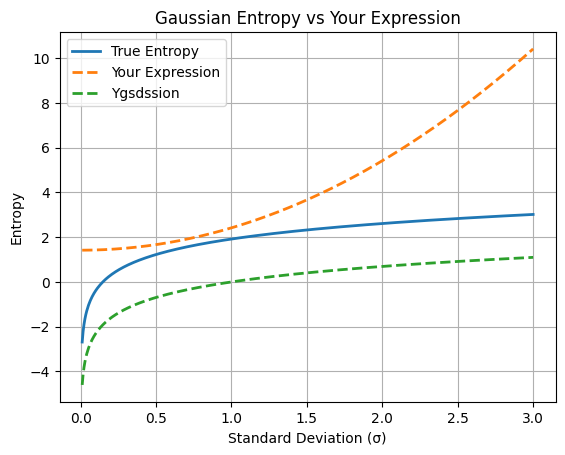

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Range of standard deviations
stds = np.linspace(0.01, 3.0, 500)

# True entropy of Gaussian: (1/2) * log(2πeσ²)
true_entropy = 0.5 * (np.log(2 * np.pi * np.e * stds**2) + 1)

# Your expression: 0.5 * (log(2πe) + 2 * std²)
approx_entropy = 0.5 * (np.log(2 * np.pi * np.e) + 2 * stds**2)

test = jnp.log(stds)

plt.plot(stds, true_entropy, label="True Entropy", linewidth=2)
plt.plot(stds, approx_entropy, label="Your Expression", linestyle="--", linewidth=2)
plt.plot(stds, test, label="Ygsdssion", linestyle="--", linewidth=2)
plt.xlabel("Standard Deviation (σ)")
plt.ylabel("Entropy")
plt.title("Gaussian Entropy vs Your Expression")
plt.legend()
plt.grid(True)
plt.show()


Testing sampling distribution...


100%|██████████| 10000/10000 [00:48<00:00, 206.17it/s]


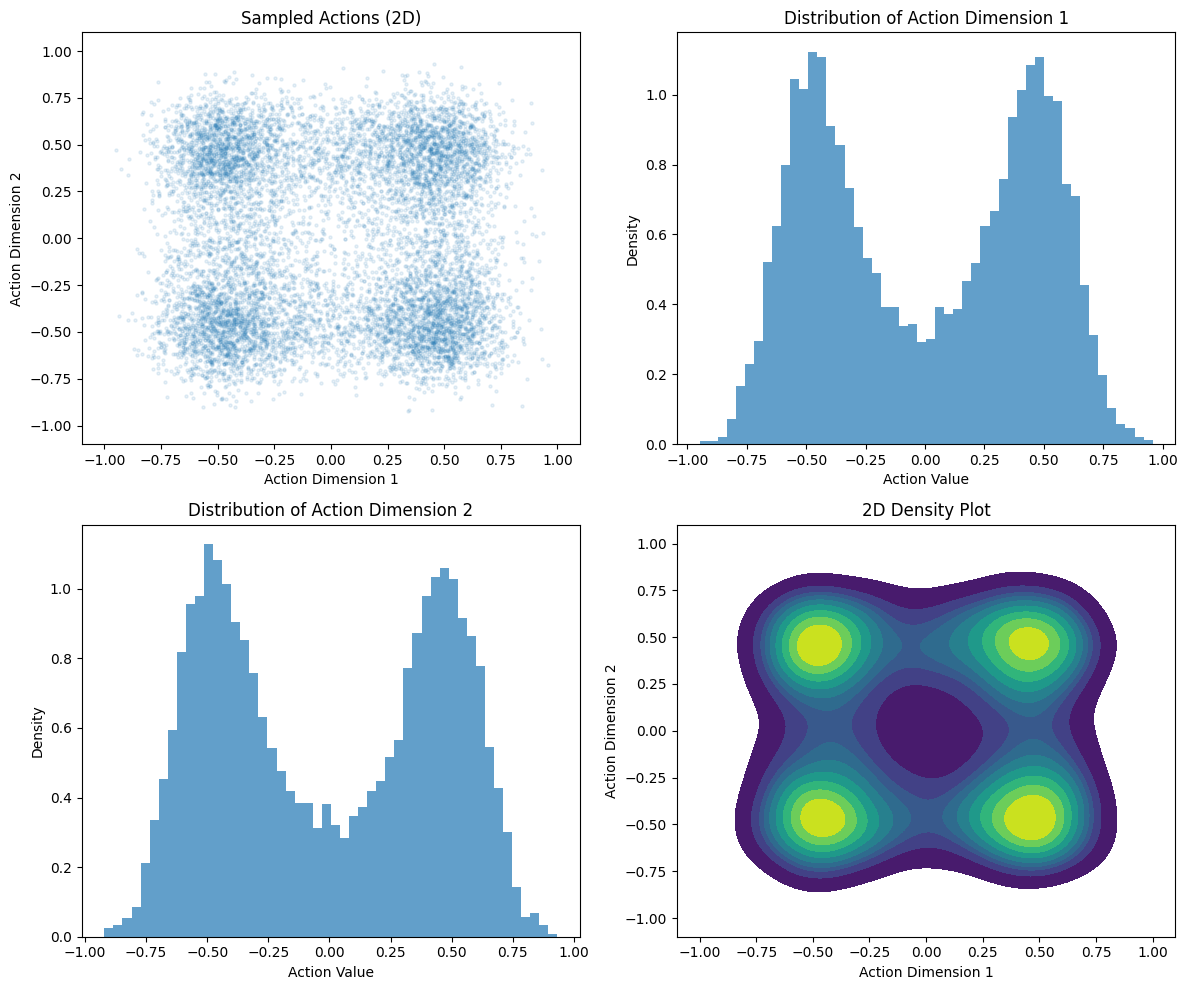

Sampling test completed!
Testing log probability calculation...
Testing sampling distribution...


100%|██████████| 10000/10000 [00:50<00:00, 199.12it/s]


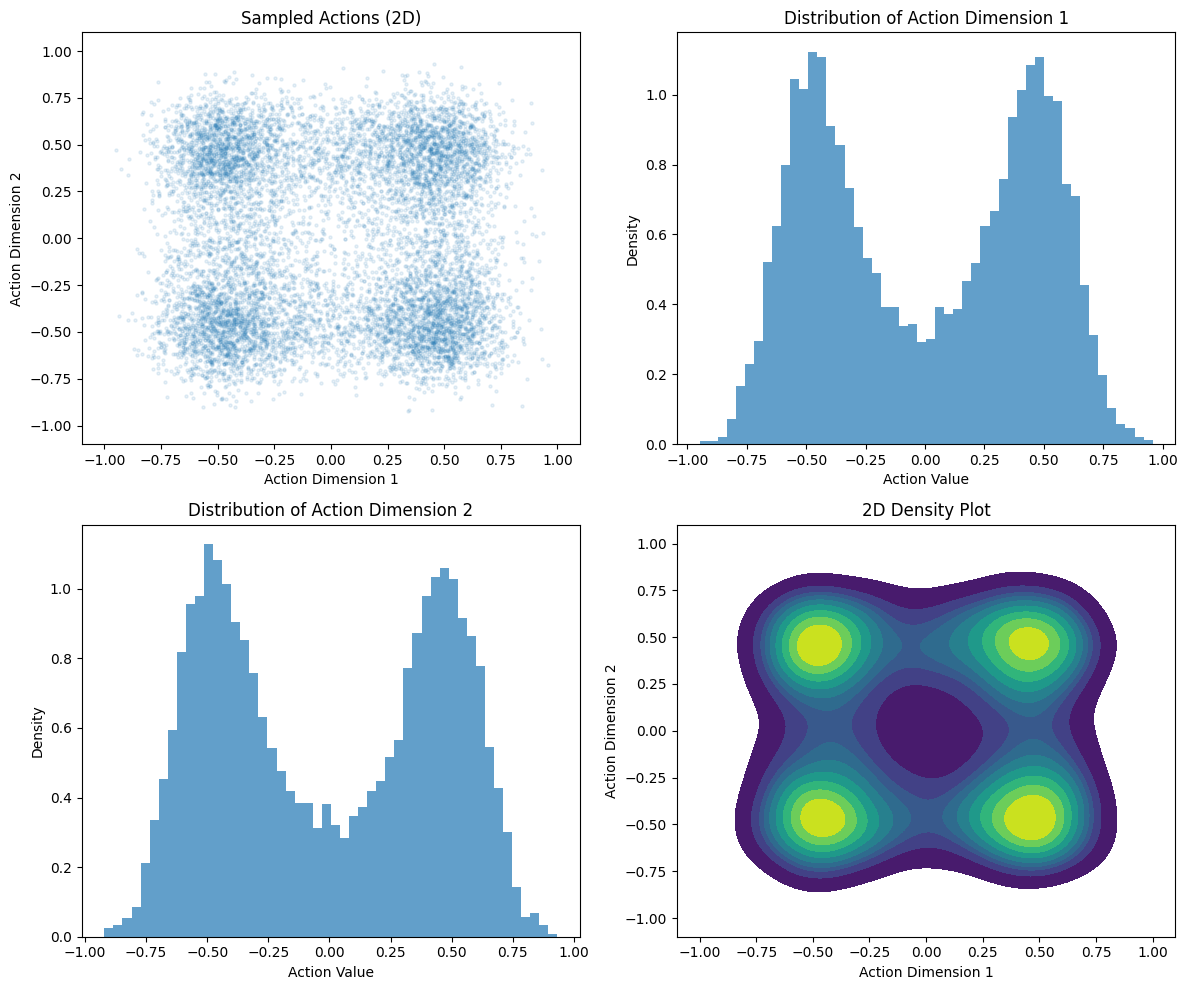

Sampling test completed!


100%|██████████| 50/50 [00:10<00:00,  4.66it/s]


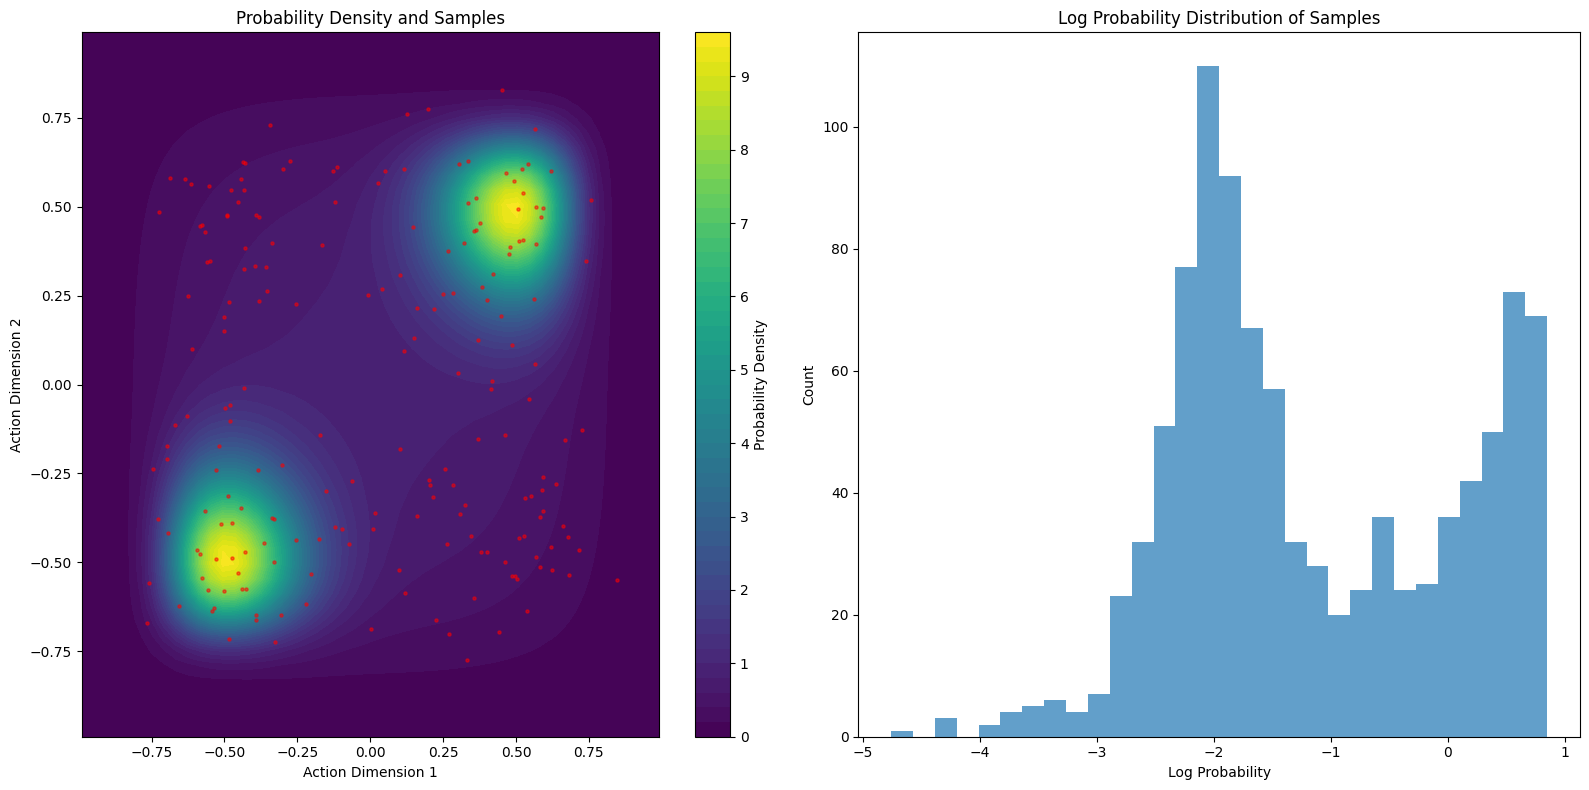

Sum of probabilities over grid: 1.0000 (should be close to 1)
Log probability test completed!
Testing entropy calculation...


  0%|          | 0/10 [00:00<?, ?it/s]


ValueError: Cannot broadcast to shape with fewer dimensions: arr_shape=(1, 1, 1, 2) shape=(1, 1, 2)

In [ ]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
from tqdm import tqdm
from scipy.stats import norm

# Dummy SamplingImplBase class for testing purposes
class SamplingImplBase:
    def __init__(self, batch_size, action_dim, sample_distribution):
        self.batch_size = batch_size
        self.action_dim = action_dim
        self.sample_distribution = sample_distribution
        
    def apply_padding_mask(self, acts, masks):
        # Simple implementation for testing
        if masks is not None:
            masks = jnp.broadcast_to(masks, acts.shape)
            return jnp.where(masks, acts, -2.0)
        return acts

# Import your implementation
class CorrelatedGaussianMixture(SamplingImplBase):
    # Your implementation here (copy from previous response)
    # ...
    
    def sampling_differ(self, act_logits, key, masks):
        # Get number of parallel environments
        N = act_logits.shape[0]
        
        # Split the logits into weight parameters and GMM parameters
        weight_logits_size = self.sample_distribution * self.action_dim * self.batch_size
        weight_logits = act_logits[..., :weight_logits_size]
        gmm_params = act_logits[..., weight_logits_size:]
        
        # Reshape weight logits to appropriate dimensions
        weight_logits = jnp.reshape(weight_logits, (N, self.batch_size, self.action_dim, self.sample_distribution))
        
        # Split GMM parameters into means and standard deviations
        means, std = jnp.split(gmm_params, 2, axis=-1)
        
        # Reshape and broadcast means to match the dimensions we need
        means_all = jnp.reshape(means, (N, 1, self.sample_distribution))
        means_all = jnp.expand_dims(jnp.broadcast_to(means_all, (N, self.batch_size, self.sample_distribution)), axis=2)
        means_all = jnp.broadcast_to(means_all, (N, self.batch_size, self.action_dim, self.sample_distribution))
        
        # Reshape and broadcast scales to match the dimensions we need
        scale_all = jnp.reshape(std, (N, 1, self.sample_distribution))
        scale_all = jnp.expand_dims(jnp.broadcast_to(scale_all, (N, self.batch_size, self.sample_distribution)), axis=2)
        scale_all = jnp.broadcast_to(scale_all, (N, self.batch_size, self.action_dim, self.sample_distribution))
        
        # Split random key for component selection and noise generation
        key_cat, key_noise = jax.random.split(key)
        
        # Sample mixture component indices based on weights for each action dimension separately
        # This allows different components to be chosen for different action dimensions
        component_indices = jax.random.categorical(key_cat, logits=weight_logits, axis=-1)
        
        # Create indexing arrays to gather the correct means and scales
        batch_indices = jnp.arange(N)[:, None, None]
        batch_indices = jnp.broadcast_to(batch_indices, component_indices.shape)
        
        sample_indices = jnp.arange(self.batch_size)[None, :, None]
        sample_indices = jnp.broadcast_to(sample_indices, component_indices.shape)
        
        action_indices = jnp.arange(self.action_dim)[None, None, :]
        action_indices = jnp.broadcast_to(action_indices, component_indices.shape)
        
        # Gather the chosen means and scales based on component indices
        chosen_means = means_all[batch_indices, sample_indices, action_indices, component_indices]
        chosen_scales = scale_all[batch_indices, sample_indices, action_indices, component_indices]
        
        # Sample noise from standard normal distribution
        noise = jax.random.normal(key_noise, shape=(N, self.batch_size, self.action_dim))
        
        # Compute the final sampled actions
        acts_tick = chosen_means + chosen_scales * noise  # shape: (N, batch_size, action_dim)
        
        # Apply tanh to constrain actions to [-1, 1] range
        acts_tick = jnp.tanh(acts_tick)
        
        # Apply padding mask if necessary
        if masks is not None:
            acts_tick = self.apply_padding_mask(acts_tick, masks)
        
        return acts_tick
    
    def gaussian_log_prob(self, actions, act_logits):
        """
        Calculate the log probability of actions under a Correlated Gaussian Mixture Model.
        
        Args:
            actions: Shape (N, T, batch_size, action_dim) - Actions to evaluate
            act_logits: Shape (N, T, total_dim) - Logits containing GMM parameters
        
        Returns:
            log_prob: Shape (N, T) - Log probability of each action
        """
        epsilon = 1e-6  # Small constant for numerical stability
        
        # Extract dimensions
        N, T = actions.shape[0], actions.shape[1]
        
        # Ensure act_logits has the right shape
        if len(act_logits.shape) == 4:  # If it has an extra dimension
            act_logits = act_logits.squeeze(2)  # Shape: (N, T, total_dim)
        
        # Split into weight logits and GMM parameters
        weight_logits_size = self.sample_distribution * self.action_dim * self.batch_size
        weight_logits = act_logits[..., :weight_logits_size]
        gmm_params = act_logits[..., weight_logits_size:]
        
        # Split GMM parameters into means and standard deviations
        means, std = jnp.split(gmm_params, 2, axis=-1)
        
        # Reshape weight logits to appropriate dimensions
        weight_logits = jnp.reshape(weight_logits, (N, T, self.batch_size, self.action_dim, self.sample_distribution))
        
        # Apply softmax to get actual mixture weights
        log_weights = jax.nn.log_softmax(weight_logits, axis=-1)
        
        # Reshape means and stds for broadcasting
        means_all = jnp.reshape(means, (N, T, 1, self.sample_distribution))
        means_all = jnp.expand_dims(jnp.broadcast_to(means_all, (N, T, self.batch_size, self.sample_distribution)), axis=3)
        means_all = jnp.broadcast_to(means_all, (N, T, self.batch_size, self.action_dim, self.sample_distribution))
        
        scale_all = jnp.reshape(std, (N, T, 1, self.sample_distribution))
        scale_all = jnp.expand_dims(jnp.broadcast_to(scale_all, (N, T, self.batch_size, self.sample_distribution)), axis=3)
        scale_all = jnp.broadcast_to(scale_all, (N, T, self.batch_size, self.action_dim, self.sample_distribution))
        
        # Create validity mask
        valid_mask = (actions[..., 0] != -2)  # Shape: (N, T, batch_size)
        
        # Apply arctanh to convert from [-1, 1] to unbounded space
        u = jnp.arctanh(jnp.clip(actions, -1 + epsilon, 1 - epsilon))  # Shape: (N, T, batch_size, action_dim)
        
        # Expand dimensions for GMM computation
        u_expanded = jnp.expand_dims(u, axis=-1)  # Shape: (N, T, batch_size, action_dim, 1)
        
        # Calculate Gaussian log probabilities for each component and action dimension
        # Shape: (N, T, batch_size, action_dim, sample_distribution)
        gaussian_log_probs = -0.5 * (((u_expanded - means_all) / scale_all) ** 2) \
                            - jnp.log(scale_all) \
                            - 0.5 * jnp.log(2 * jnp.pi)
        
        # Sum log probabilities across action dimensions
        # Shape: (N, T, batch_size, sample_distribution)
        summed_action_log_probs = jnp.sum(gaussian_log_probs, axis=3)
        
        # Calculate mixture log probability using logsumexp across components
        # Shape: (N, T, batch_size)
        batch_log_probs = jax.scipy.special.logsumexp(
            log_weights[..., 0, :] + summed_action_log_probs, axis=-1)
        
        # Add correction term for tanh transformation
        # Shape: (N, T, batch_size, action_dim)
        log_det_jacobian = jnp.sum(jnp.log(1 - actions ** 2 + epsilon), axis=-1)
        
        # Apply correction
        # Shape: (N, T, batch_size)
        batch_log_probs = batch_log_probs - log_det_jacobian
        
        # Zero out invalid batches
        # Shape: (N, T, batch_size)
        masked_log_probs = jnp.where(valid_mask, batch_log_probs, 0.0)
        
        # Sum across batches
        # Shape: (N, T)
        log_prob = jnp.sum(masked_log_probs, axis=-1)
        
        return log_prob
    
    def entropy(self, logits, mask):
        """
        Calculate the entropy of a Correlated Gaussian Mixture Model with tanh transformation.
        
        Args:
            logits: Shape (N, S, total_dim) - Logits containing GMM parameters
            mask: Shape (N, S, batch_size, 1) - Mask for valid samples
            
        Returns:
            entropy: Shape (N, S) - Entropy of the distribution
        """
        # Extract dimensions
        N, S = logits.shape[0], logits.shape[1]
        
        # Reshape logits if needed
        if len(logits.shape) == 3:
            logits = jnp.reshape(logits, (N, S, 1, logits.shape[-1]))
        
        # Split into weight logits and GMM parameters
        weight_logits_size = self.sample_distribution * self.action_dim * self.batch_size
        weight_logits = logits[..., :weight_logits_size]
        gmm_params = logits[..., weight_logits_size:]
        
        # Split GMM parameters into means and standard deviations
        means, std = jnp.split(gmm_params, 2, axis=-1)
        
        # Reshape weight logits and apply softmax to get mixture weights
        weight_logits = jnp.reshape(weight_logits, (N, S, self.batch_size, self.action_dim, self.sample_distribution))
        weights = jax.nn.softmax(weight_logits, axis=-1)
        log_weights = jax.nn.log_softmax(weight_logits, axis=-1)
        
        # Reshape means and stds for broadcasting
        means_all = jnp.reshape(means, (N, S, 1, self.sample_distribution))
        means_all = jnp.expand_dims(jnp.broadcast_to(means_all, (N, S, self.batch_size, self.sample_distribution)), axis=3)
        means_all = jnp.broadcast_to(means_all, (N, S, self.batch_size, self.action_dim, self.sample_distribution))
        
        scale_all = jnp.reshape(std, (N, S, 1, self.sample_distribution))
        scale_all = jnp.expand_dims(jnp.broadcast_to(scale_all, (N, S, self.batch_size, self.sample_distribution)), axis=3)
        scale_all = jnp.broadcast_to(scale_all, (N, S, self.batch_size, self.action_dim, self.sample_distribution))
        
        # For a Gaussian mixture, the entropy doesn't have a closed form solution
        # We'll use a Monte Carlo approximation with importance sampling
        n_samples = 50  # Number of samples for approximation
        
        # Generate sample keys
        key = jax.random.PRNGKey(0)
        keys = jax.random.split(key, n_samples)
        
        # Initialize accumulator for entropy approximation
        entropy_approx = jnp.zeros((N, S, self.batch_size))
        
        # For each sample
        for i in range(n_samples):
            # Sample component indices for each batch and action dimension
            key_comp = keys[i]
            comp_indices = jax.random.categorical(key_comp, logits=weight_logits, axis=-1)
            
            # Create indexing arrays
            batch_indices = jnp.arange(N)[:, None, None]
            batch_indices = jnp.broadcast_to(batch_indices, comp_indices.shape)
            
            step_indices = jnp.arange(S)[None, :, None]
            step_indices = jnp.broadcast_to(step_indices, comp_indices.shape)
            
            sample_indices = jnp.arange(self.batch_size)[None, None, :]
            sample_indices = jnp.broadcast_to(sample_indices, comp_indices.shape)
            
            action_indices = jnp.arange(self.action_dim)[None, None, None, :]
            action_indices = jnp.broadcast_to(action_indices, (*comp_indices.shape, self.action_dim))
            
            # Get selected components' means and scales
            sel_means = means_all[batch_indices, step_indices, sample_indices, :, comp_indices]
            sel_scales = scale_all[batch_indices, step_indices, sample_indices, :, comp_indices]
            
            # Generate noise
            key_noise = jax.random.split(key_comp)[0]
            noise = jax.random.normal(key_noise, shape=sel_means.shape)
            
            # Generate samples in unbounded space
            u_samples = sel_means + sel_scales * noise
            
            # Apply tanh transformation
            x_samples = jnp.tanh(u_samples)
            
            # Calculate log probability of these samples
            # First, expand dimensions for processing
            x_samples_expanded = jnp.expand_dims(x_samples, axis=-1)
            u_samples_expanded = jnp.expand_dims(u_samples, axis=-1)
            
            # Calculate Gaussian log probabilities for each component
            gauss_log_probs = -0.5 * (((u_samples_expanded - means_all) / scale_all) ** 2) \
                            - jnp.log(scale_all) \
                            - 0.5 * jnp.log(2 * jnp.pi)
            
            # Sum over action dimensions
            gauss_log_probs_sum = jnp.sum(gauss_log_probs, axis=3)
            
            # Add log weights and use logsumexp for numerical stability
            mixture_log_probs = jax.scipy.special.logsumexp(
                log_weights[..., 0, :] + gauss_log_probs_sum, axis=-1)
            
            # Calculate log determinant of Jacobian for tanh transformation
            log_det_jacobian = jnp.sum(jnp.log(1 - x_samples ** 2 + 1e-6), axis=-1)
            
            # Final log probability
            log_probs = mixture_log_probs - log_det_jacobian
            
            # Update entropy approximation
            entropy_approx -= log_probs / n_samples
        
        # Apply mask
        mask = jnp.squeeze(mask, axis=-1)  # Remove last dimension if it's 1
        mask = jnp.broadcast_to(mask, (N, S, self.batch_size))
        masked_entropy = jnp.where(mask, entropy_approx, 0.0)
        
        # Sum over batch dimension
        final_entropy = jnp.sum(masked_entropy, axis=-1)
        
        return final_entropy

# Test Functions

def test_sampling_distribution():
    """
    Test if sampling produces distributions that match the expected GMM parameters.
    Generates visualizations of sampled actions vs expected probability densities.
    """
    print("Testing sampling distribution...")
    
    # Initialize parameters
    batch_size = 1
    action_dim = 2
    sample_distribution = 3  # 3 mixture components
    N = 1  # Single environment
    
    # Create the model
    model = CorrelatedGaussianMixture(batch_size, action_dim, sample_distribution)
    
    # Create sample parameters - we'll have 3 distinct components
    # Component 1: Mean at (-0.5, -0.5) with std 0.2
    # Component 2: Mean at (0.5, 0.5) with std 0.2
    # Component 3: Mean at (0.0, 0.0) with std 0.5
    
    # Equal weights (logits) for all components
    weight_logits = jnp.zeros((N, batch_size, action_dim, sample_distribution))
    
    # Set means and scales for components
    means = jnp.array([[-0.5, 0.5, 0.0]])  # (N, sample_distribution)
    scales = jnp.array([[0.2, 0.2, 0.5]])  # (N, sample_distribution)
    
    # Combine parameters into logits
    total_dim = weight_logits_size = sample_distribution * action_dim * batch_size
    act_logits = jnp.zeros((N, total_dim * 2))
    
    # Flatten weight logits to insert into act_logits
    flat_weight_logits = weight_logits.reshape((N, -1))
    act_logits = act_logits.at[:, :flat_weight_logits.shape[1]].set(flat_weight_logits)
    
    # Insert means and scales
    act_logits = act_logits.at[:, total_dim:total_dim+means.shape[1]].set(means)
    act_logits = act_logits.at[:, total_dim+means.shape[1]:].set(scales)
    
    # Generate large number of samples for visualization
    num_samples = 10000
    samples = []
    
    key = jax.random.PRNGKey(42)
    for _ in tqdm(range(num_samples)):
        key, subkey = jax.random.split(key)
        acts = model.sampling_differ(act_logits, subkey, None)
        samples.append(acts[0, 0].copy())  # Only keep first batch sample
    
    samples = jnp.array(samples)
    
    # Create plot
    plt.figure(figsize=(12, 10))
    
    # Scatter plot of samples
    plt.subplot(2, 2, 1)
    plt.scatter(samples[:, 0], samples[:, 1], alpha=0.1, s=5)
    plt.title("Sampled Actions (2D)")
    plt.xlabel("Action Dimension 1")
    plt.ylabel("Action Dimension 2")
    plt.xlim(-1.1, 1.1)
    plt.ylim(-1.1, 1.1)
    
    # Histograms
    plt.subplot(2, 2, 2)
    plt.hist(samples[:, 0], bins=50, density=True, alpha=0.7)
    plt.title("Distribution of Action Dimension 1")
    plt.xlabel("Action Value")
    plt.ylabel("Density")
    
    plt.subplot(2, 2, 3)
    plt.hist(samples[:, 1], bins=50, density=True, alpha=0.7)
    plt.title("Distribution of Action Dimension 2")
    plt.xlabel("Action Value")
    plt.ylabel("Density")
    
    # 2D density plot
    plt.subplot(2, 2, 4)
    sns.kdeplot(x=samples[:, 0], y=samples[:, 1], cmap="viridis", fill=True, thresh=0.05)
    plt.title("2D Density Plot")
    plt.xlabel("Action Dimension 1")
    plt.ylabel("Action Dimension 2")
    plt.xlim(-1.1, 1.1)
    plt.ylim(-1.1, 1.1)
    
    plt.tight_layout()
    plt.show()
    
    print("Sampling test completed!")
    
    return samples, act_logits

def test_log_prob():
    """
    Test if the log probability calculation is accurate by checking:
    1. If higher density regions have higher log probs
    2. If log prob sums to 1 when integrated over the action space
    """
    print("Testing log probability calculation...")
    
    # Get samples and logits from sampling test
    samples, act_logits = test_sampling_distribution()
    
    # Initialize parameters
    batch_size = 1
    action_dim = 2
    sample_distribution = 3
    N = 1
    T = 1  # Single time step
    
    # Create the model
    model = CorrelatedGaussianMixture(batch_size, action_dim, sample_distribution)
    
    # Expand dimensions for log prob calculation
    act_logits_expanded = jnp.expand_dims(act_logits, axis=1)  # (N, T, total_dim)
    
    # Calculate log probabilities for a grid of points
    resolution = 50
    x = jnp.linspace(-0.99, 0.99, resolution)
    y = jnp.linspace(-0.99, 0.99, resolution)
    X, Y = jnp.meshgrid(x, y)
    
    Z = jnp.zeros_like(X)
    
    # Create grid of actions
    for i in tqdm(range(resolution)):
        for j in range(resolution):
            # Create action array with shape (N, T, batch_size, action_dim)
            action = jnp.array([[[[X[i, j], Y[i, j]]]]])
            
            # Calculate log probability
            log_prob = model.gaussian_log_prob(action, act_logits_expanded)
            Z = Z.at[i, j].set(log_prob[0, 0])
    
    # Convert log probabilities to probabilities for visualization
    P = jnp.exp(Z)
    
    # Normalize to ensure it's a proper probability density
    # (note: this is approximate since we're using a discrete grid)
    P = P / jnp.sum(P) * (resolution**2)
    
    # Calculate log probabilities for sample points
    sample_log_probs = []
    for i in range(min(1000, len(samples))):  # limit to 1000 samples to save computation
        action = jnp.array([[[[samples[i, 0], samples[i, 1]]]]])
        log_prob = model.gaussian_log_prob(action, act_logits_expanded)
        sample_log_probs.append(log_prob[0, 0])
    
    sample_log_probs = jnp.array(sample_log_probs)
    
    # Create visualization
    plt.figure(figsize=(16, 8))
    
    # Plot probability density
    plt.subplot(1, 2, 1)
    contour = plt.contourf(X, Y, P.T, levels=50, cmap='viridis')
    plt.colorbar(contour, label='Probability Density')
    plt.scatter(samples[:200, 0], samples[:200, 1], color='red', alpha=0.5, s=5)
    plt.title("Probability Density and Samples")
    plt.xlabel("Action Dimension 1")
    plt.ylabel("Action Dimension 2")
    
    # Plot log probability distribution
    plt.subplot(1, 2, 2)
    plt.hist(sample_log_probs, bins=30, alpha=0.7)
    plt.title("Log Probability Distribution of Samples")
    plt.xlabel("Log Probability")
    plt.ylabel("Count")
    
    plt.tight_layout()
    plt.show()
    
    # Check if the probabilities integrate to approximately 1
    total_prob = jnp.sum(P) / (resolution**2)
    print(f"Sum of probabilities over grid: {total_prob:.4f} (should be close to 1)")
    
    print("Log probability test completed!")
    
    return Z, sample_log_probs

def test_entropy():
    """
    Test entropy calculation and visualize how it changes with different mixture parameters
    """
    print("Testing entropy calculation...")
    
    # Initialize parameters
    batch_size = 1
    action_dim = 2
    sample_distribution = 2  # 2 mixture components for simplicity
    N = 1
    S = 1  # Single time step
    
    # Create the model
    model = CorrelatedGaussianMixture(batch_size, action_dim, sample_distribution)
    
    # Test entropy with varying scales
    scales = np.linspace(0.1, 1.0, 10)
    entropies = []
    
    for scale in tqdm(scales):
        # Setup parameters for a balanced 2-component mixture
        weight_logits = jnp.zeros((N, S, batch_size, action_dim, sample_distribution))
        
        # Set means: Component 1 at -0.5, Component 2 at 0.5
        means = jnp.array([[[[-0.5, 0.5]]]])
        
        # Set scales (same for both components)
        scales_array = jnp.array([[[[scale, scale]]]])
        
        # Combine parameters into logits
        total_dim = sample_distribution * action_dim * batch_size
        act_logits = jnp.zeros((N, S, total_dim * 2))
        
        # Flatten weight logits to insert into act_logits
        flat_weight_logits = weight_logits.reshape((N, S, -1))
        act_logits = act_logits.at[:, :, :flat_weight_logits.shape[2]].set(flat_weight_logits)
        
        # Insert means and scales
        act_logits = act_logits.at[:, :, total_dim:total_dim+means.shape[3]].set(means)
        act_logits = act_logits.at[:, :, total_dim+means.shape[3]:].set(scales_array)
        
        # Calculate entropy
        mask = jnp.ones((N, S, batch_size, 1))
        entropy = model.entropy(act_logits, mask)
        entropies.append(entropy[0, 0])
    
    # Now test entropy with varying mixture weights
    weights_param = np.linspace(0, 5, 10)  # Controls how unbalanced the mixture is
    weight_entropies = []
    
    for w in tqdm(weights_param):
        # Create weight logits - we'll make the first component more likely as w increases
        weight_logits = jnp.zeros((N, S, batch_size, action_dim, sample_distribution))
        weight_logits = weight_logits.at[:, :, :, :, 0].set(w)  # Favor first component
        
        # Fixed means and scales
        means = jnp.array([[[[-0.5, 0.5]]]])
        scales_array = jnp.array([[[[0.3, 0.3]]]])
        
        # Combine parameters into logits
        total_dim = sample_distribution * action_dim * batch_size
        act_logits = jnp.zeros((N, S, total_dim * 2))
        
        # Flatten weight logits to insert into act_logits
        flat_weight_logits = weight_logits.reshape((N, S, -1))
        act_logits = act_logits.at[:, :, :flat_weight_logits.shape[2]].set(flat_weight_logits)
        
        # Insert means and scales
        act_logits = act_logits.at[:, :, total_dim:total_dim+means.shape[3]].set(means)
        act_logits = act_logits.at[:, :, total_dim+means.shape[3]:].set(scales_array)
        
        # Calculate entropy
        mask = jnp.ones((N, S, batch_size, 1))
        entropy = model.entropy(act_logits, mask)
        weight_entropies.append(entropy[0, 0])
    
    # Create visualization
    plt.figure(figsize=(14, 6))
    
    # Plot entropy vs scale
    plt.subplot(1, 2, 1)
    plt.plot(scales, entropies, 'o-')
    plt.title("Entropy vs. Scale")
    plt.xlabel("Scale Parameter")
    plt.ylabel("Entropy")
    plt.grid(True)
    
    # Plot entropy vs weight balance
    plt.subplot(1, 2, 2)
    
    # Convert weight parameter to actual mixture probability
    probs = [jax.nn.softmax(jnp.array([w, 0]))[0].item() for w in weights_param]
    
    plt.plot(probs, weight_entropies, 'o-')
    plt.title("Entropy vs. Mixture Weight of First Component")
    plt.xlabel("Probability of Component 1")
    plt.ylabel("Entropy")
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Expected behavior explanations
    print("\nEntropy Expectations:")
    print("1. Entropy should increase with scale (more uncertainty)")
    print("2. Entropy should be highest when mixture weights are balanced (probability = 0.5)")
    print("3. Entropy should decrease as one component dominates (prob -> 0 or prob -> 1)")
    
    print("\nEntropy test completed!")
    
    return entropies, weight_entropies


test_sampling_distribution()
test_log_prob()
test_entropy()


In [ ]:
class SamplingImplBase:
    def __init__(self, max_batch, action_dim, sampling_distribution=1):
        self.sample_distribution = sampling_distribution
        self.action_dim = action_dim
        self.batch_size = max_batch
    
    """Shared utilities (only apply_padding_mask). All actual sampling logic is abstract."""
    def apply_padding_mask(self, actions, masks, pad_value=-2.0):
        x,n,z = actions.shape
        batch_idx = jnp.arange(n)
        mask = batch_idx < masks.reshape(x,1)
        full = jnp.broadcast_to(mask.reshape(x,n,1),(x,n,z))
        return jnp.where(full, actions, pad_value)
    
    def sampling_differ(self, act_logits, key, masks):
        raise NotImplementedError

    def gaussian_log_prob(self, actions, logits):
        raise NotImplementedError

    def entropy(self, logits, mask):
        raise NotImplementedError


class CorrelatedGaussianMixture(SamplingImplBase):

    def sampling_differ(self, act_logits, key, masks):
        N = act_logits.shape[0]

        weight_logits_size = self.sample_distribution * self.action_dim * self.batch_size
        weight_logits = act_logits[..., :weight_logits_size]
        gmm_params = act_logits[..., weight_logits_size:]

        # === Updated Reshaping ===
        weight_logits = jnp.reshape(weight_logits, (N, self.batch_size, self.action_dim, self.sample_distribution))
        means, std = jnp.split(gmm_params, 2, axis=-1)
        means_all = jnp.reshape(means, (N, self.batch_size, self.action_dim, self.sample_distribution))
        scale_all = jnp.reshape(std,   (N, self.batch_size, self.action_dim, self.sample_distribution))

        # Random keys
        key_cat, key_noise = jax.random.split(key)
        component_indices = jax.random.categorical(key_cat, logits=weight_logits, axis=-1)

        # Indexing arrays
        batch_indices = jnp.arange(N)[:, None, None]
        batch_indices = jnp.broadcast_to(batch_indices, component_indices.shape)

        sample_indices = jnp.arange(self.batch_size)[None, :, None]
        sample_indices = jnp.broadcast_to(sample_indices, component_indices.shape)

        action_indices = jnp.arange(self.action_dim)[None, None, :]
        action_indices = jnp.broadcast_to(action_indices, component_indices.shape)

        # Gather chosen means and stds
        chosen_means = means_all[batch_indices, sample_indices, action_indices, component_indices]
        chosen_scales = scale_all[batch_indices, sample_indices, action_indices, component_indices]

        noise = jax.random.normal(key_noise, shape=(N, self.batch_size, self.action_dim))
        acts_tick = chosen_means + chosen_scales * noise

        acts_tick = jnp.tanh(acts_tick)

        if masks is not None:
            acts_tick = self.apply_padding_mask(acts_tick, masks)

        return acts_tick


    def gaussian_log_prob(self, actions, act_logits):
        """Compute a stable log-probability for a GMM (including the tanh correction)."""
        epsilon = 1e-6
        N = act_logits.shape[0]
        # Split act_logits into mixture weight logits and GMM parameters.
        weight_logits_size = self.sample_distribution * self.action_dim * self.batch_size
        weight_logits = act_logits[..., :weight_logits_size]
        gmm_params = act_logits[..., weight_logits_size:]
        
        # print("okmesa ", weight_logits.shape, gmm_params.shape, self.sample_distribution, self.action_dim, self.batch_size)

        # Reshape weight_logits to (N, batch_size, action_dim, sample_distribution)
        weight_logits = jnp.reshape(weight_logits, (N, self.batch_size, self.action_dim, self.sample_distribution))
        # Convert logits to probabilities.
        weights = jax.nn.softmax(weight_logits, axis=-1)

        # Split GMM parameters into means and scales, then reshape to (N, batch_size, action_dim, sample_distribution)
        means, stds = jnp.split(gmm_params, 2, axis=-1)
        means = jnp.reshape(means, (N, self.batch_size, self.action_dim, self.sample_distribution))
        stds = jnp.reshape(stds, (N, self.batch_size, self.action_dim, self.sample_distribution))

        # Unsquash the actions: a = tanh(u)  => u = atanh(a)
        u = jnp.arctanh(jnp.clip(actions, -1 + epsilon, 1 - epsilon))
        u_expanded = jnp.expand_dims(u, axis=-1)  # shape: (N, batch_size, action_dim, 1)

        # Compute the log probability for each mixture component.
        log_probs_components = jax.scipy.stats.norm.logpdf(u_expanded, means, stds)
        log_weights = jnp.log(weights + epsilon)
        log_component = log_weights + log_probs_components

        # Aggregate the per-component densities using logsumexp over the mixture dimension.
        log_prob_per_dim = jax.scipy.special.logsumexp(log_component, axis=-1)  # shape: (N, batch_size, action_dim)
        # print(log_prob_per_dim.shape)
        base_log_prob = jnp.sum(log_prob_per_dim, axis=-1)      # sum over action dimensions

        # Compute the log-determinant of the tanh Jacobian:
        # A numerically stable expression: 2 * (log(2) - u - softplus(-2*u))
        log_det_jacobian = jnp.sum(2 * (jnp.log(2) - u - jax.nn.softplus(-2 * u)), axis=-1)

        return base_log_prob - log_det_jacobian

    def entropy(self, act_logits, mask):
        """
        Compute the entropy of a tanh-squashed GMM using quantile approximation.
        
        Args:
            act_logits: [N, S, distribution_params] - includes mixture weights, means, stds
            mask: [N, S, 1] or [N, S] - indicates valid entries

        Returns:
            [N, S] - entropy per environment per step
        """
        N, S = act_logits.shape[:2]
        flat_act_logits = jnp.reshape(act_logits, (N, S, -1))

        weight_logits_size = self.sample_distribution * self.action_dim * self.batch_size
        weight_logits = flat_act_logits[..., :weight_logits_size]
        gmm_params = flat_act_logits[..., weight_logits_size:]

        # Reshape mixture weights: (N, S, batch, action_dim, components)
        weight_logits = jnp.reshape(
            weight_logits,
            (N, S, self.batch_size, self.action_dim, self.sample_distribution),
        )
        weights = jax.nn.softmax(weight_logits, axis=-1)

        # Reshape means & stds: (N, S, batch, action_dim, components)
        means, stds = jnp.split(gmm_params, 2, axis=-1)
        means = jnp.reshape(
            means, (N, S, self.batch_size, self.action_dim, self.sample_distribution)
        )
        stds = jnp.reshape(
            stds, (N, S, self.batch_size, self.action_dim, self.sample_distribution)
        )
        stds = jnp.clip(stds, 1e-6)  # numerical stability

        # Base entropy (expectation over GMM)
        component_entropy = 0.5 * (jnp.log(2 * jnp.pi * jnp.e) + 2 * jnp.log(stds))
        entropy_per_component = jnp.sum(component_entropy, axis=3)  # sum over action dims

        # Weighted entropy + categorical entropy term
        base_entropy = jnp.sum(weights * entropy_per_component, axis=-1)  # sum over components
        categorical_entropy = -jnp.sum(weights * jnp.log(weights + 1e-8), axis=-1)
        base_entropy += categorical_entropy  # shape (N, S, batch)

        # Tanh correction using quantile approximation
        n_quantiles = 100
        qs = jnp.linspace(0.01, 0.99, n_quantiles)
        quantiles = jax.scipy.stats.norm.ppf(qs)  # shape (100,)

        # Expand dimensions for broadcasting
        quantiles = quantiles[None, None, None, None, :, None]  # shape (1,1,1,1,100,1)
        means_exp = means[..., None]  # shape (N, S, batch, action_dim, components, 1)
        stds_exp = stds[..., None]    # same shape

        # Sample x from each Gaussian component
        samples = means_exp + stds_exp * quantiles  # (N, S, batch, action_dim, components, 100)

        # log|det(Jacobian of tanh)| = log(1 - tanh^2(x)) = 2(log(2) - x - softplus(-2x))
        log_det = 2 * (jnp.log(2) - samples - jax.nn.softplus(-2 * samples))
        log_det = jnp.sum(log_det, axis=3)  # sum over action_dim

        # Average over quantiles
        log_det_avg = jnp.mean(log_det, axis=-1)  # shape: (N, S, batch, components)

        # Expectation over mixture weights
        correction = jnp.sum(weights * log_det_avg, axis=-1)  # shape (N, S, batch)

        # Final corrected entropy
        corrected_entropy = base_entropy + correction  # note: correction is negative

        # Masking invalid entries
        if mask.ndim == 3 and mask.shape[-1] == 1:
            mask = jnp.squeeze(mask, axis=-1)
        mask = jnp.broadcast_to(mask, corrected_entropy.shape)
        masked_entropy = jnp.where(mask, corrected_entropy, 0.0)

        # Sum or average across batch
        entropy = jnp.sum(masked_entropy, axis=-1) / (jnp.sum(mask, axis=-1) + 1e-8)  # shape: (N, S)

        return entropy



C:\Users\jimvo\AppData\Local\Temp\ipykernel_468\4081574733.py:48: FutureWarning: None encountered in jnp.array(); this is currently treated as NaN. In the future this will result in an error.
  samples = jnp.array(samples)


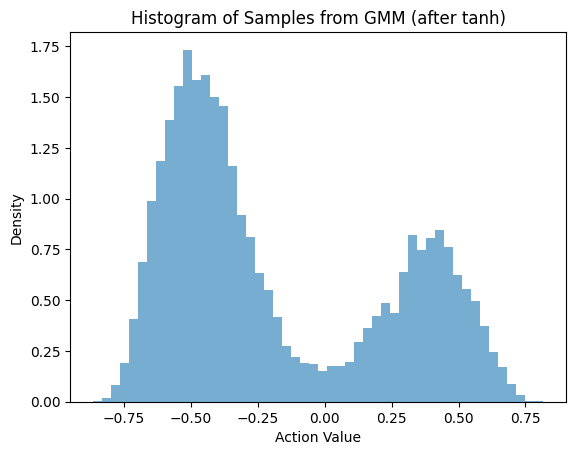

[[[-1.]]]
(1, 1, 1)
[[[-0.9899497]]]
(1, 1, 1)
[[[-0.9798995]]]
(1, 1, 1)
[[[-0.9698492]]]
(1, 1, 1)
[[[-0.95979905]]]
(1, 1, 1)
[[[-0.94974875]]]
(1, 1, 1)
[[[-0.93969846]]]
(1, 1, 1)
[[[-0.9296483]]]
(1, 1, 1)
[[[-0.919598]]]
(1, 1, 1)
[[[-0.9095477]]]
(1, 1, 1)
[[[-0.8994975]]]
(1, 1, 1)
[[[-0.8894472]]]
(1, 1, 1)
[[[-0.87939703]]]
(1, 1, 1)
[[[-0.86934674]]]
(1, 1, 1)
[[[-0.85929644]]]
(1, 1, 1)
[[[-0.84924626]]]
(1, 1, 1)
[[[-0.83919597]]]
(1, 1, 1)
[[[-0.82914567]]]
(1, 1, 1)
[[[-0.8190955]]]
(1, 1, 1)
[[[-0.8090452]]]
(1, 1, 1)
[[[-0.798995]]]
(1, 1, 1)
[[[-0.7889447]]]
(1, 1, 1)
[[[-0.7788944]]]
(1, 1, 1)
[[[-0.76884425]]]
(1, 1, 1)
[[[-0.75879395]]]
(1, 1, 1)
[[[-0.7487438]]]
(1, 1, 1)
[[[-0.7386935]]]
(1, 1, 1)
[[[-0.7286432]]]
(1, 1, 1)
[[[-0.718593]]]
(1, 1, 1)
[[[-0.7085427]]]
(1, 1, 1)
[[[-0.6984925]]]
(1, 1, 1)
[[[-0.68844223]]]
(1, 1, 1)
[[[-0.67839193]]]
(1, 1, 1)
[[[-0.66834176]]]
(1, 1, 1)
[[[-0.65829146]]]
(1, 1, 1)
[[[-0.6482413]]]
(1, 1, 1)
[[[-0.638191]]]
(1, 1, 

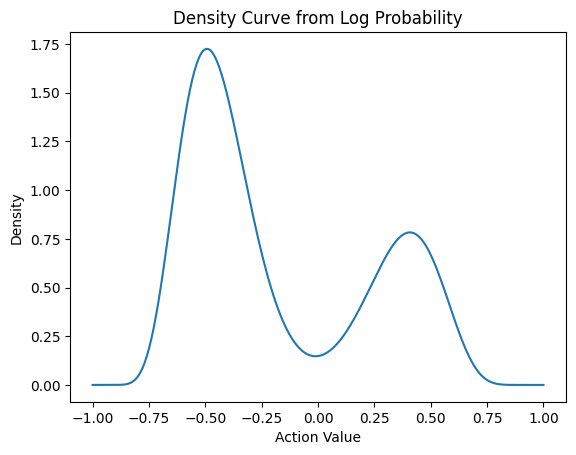

Approximate Entropy of the GMM: [0.48523661]


In [ ]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# --- Define a Test Subclass of Your GMM Sampler ---
# This dummy subclass simply sets required attributes and stubs out methods.
class TestCorrelatedGaussianMixture(CorrelatedGaussianMixture):
    def __init__(self, batch_size, action_dim, sample_distribution):
        self.batch_size = batch_size
        self.action_dim = action_dim
        self.sample_distribution = sample_distribution
        
    def apply_padding_mask(self, x, mask):
        # For testing, we assume no masking is needed.
        return x

    def ent_schedule(self, update_tick=None):
        # Dummy method for testing purposes.
        pass

# --- Instantiate the Test Class ---
# For simplicity, we use a single environment (N=1), one sample per call (batch_size=1),
# one action dimension (action_dim=1), and 2 mixture components (sample_distribution=2).
test_gmm = TestCorrelatedGaussianMixture(batch_size=1, action_dim=1, sample_distribution=2)

# --- Construct a Simple act_logits ---
# The expected structure:
#  - weight_logits: shape (N, batch_size * action_dim * sample_distribution) = (1, 2)
#  - gmm_params: means (2 values) and scales (2 values) => total of 4 values.
# Here, we set equal weights (logits of 0), means = [-1.0, 1.0], and scales = [0.1, 0.1].
# Thus, the full act_logits has shape (1, 2+4) = (1, 6).
act_logits = jnp.array([[0.8, 0.1,  -0.5, 0.4,  0.2, 0.2]])

# --- Test 1: Sampling Visualization ---
# We repeatedly sample from the GMM (using different random keys) to generate many samples.
# Since our sampling_differ returns a tanh-squashed action, with the chosen means,
# we expect a bimodal distribution (around tanh(-1) and tanh(1)).
num_samples = 10000
samples = []
key = jax.random.PRNGKey(0)
for i in range(num_samples):
    key, subkey = jax.random.split(key)
    sample = test_gmm.sampling_differ(act_logits, subkey, masks=None)
    # sample has shape (N, batch_size, action_dim); here, we extract the scalar value.
    # print(sample.shape)
    samples.append(samples.append(sample[0, 0, 0].item())
)
samples = jnp.array(samples)

plt.hist(samples, bins=50, density=True, alpha=0.6)
plt.title("Histogram of Samples from GMM (after tanh)")
plt.xlabel("Action Value")
plt.ylabel("Density")
plt.show()

# --- Test 2: Log-Probability Visualization ---
# For the log probability test, we need to provide act_logits in the shape expected by gaussian_log_prob.
# Here, we reshape it so that the second dimension (S) is 1.
act_logits_lp = act_logits.reshape((1, 1, 6))

# Evaluate log-probability over a grid of action values (in the tanh-space, i.e. between -1 and 1).
action_grid = jnp.linspace(-1, 1, 200)
log_probs = []
for a in action_grid:
    # Create an action with shape (N, batch_size, action_dim) = (1,1,1)
    action_val = jnp.array([[[a]]])
    print(action_val)
    lp = test_gmm.gaussian_log_prob(action_val, act_logits_lp)
    log_probs.append(lp[0,0])
log_probs = jnp.array(log_probs)
density = jnp.exp(log_probs)  # Convert log probability to density

plt.plot(action_grid, density)
plt.title("Density Curve from Log Probability")
plt.xlabel("Action Value")
plt.ylabel("Density")
plt.show()

# --- Test 3: Entropy Check ---
# For the entropy method, we construct a mask (all ones means no masking).
mask = jnp.ones((1, 1, 1))
entropy_value = test_gmm.entropy(act_logits_lp, mask)
print("Approximate Entropy of the GMM:", entropy_value)


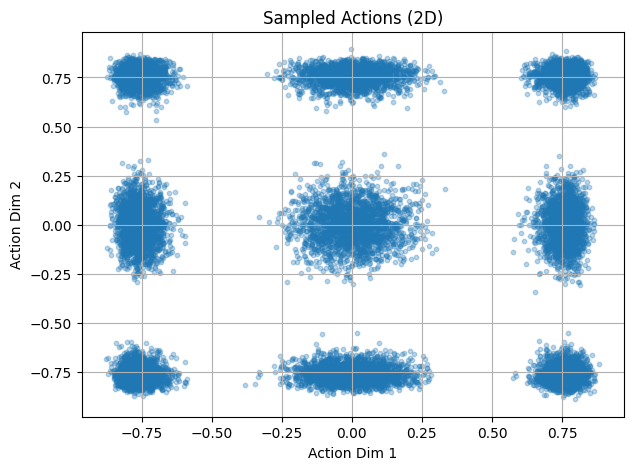

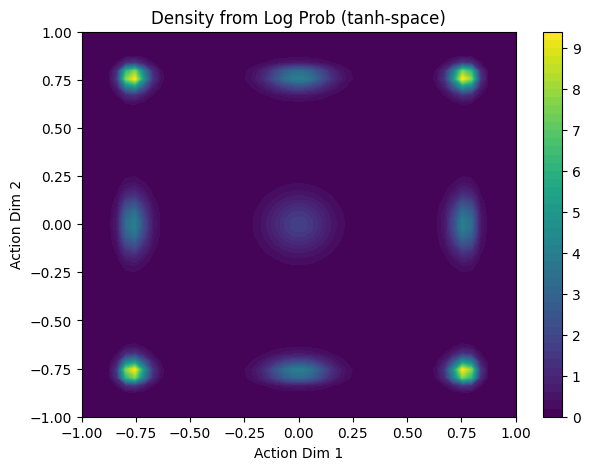

ValueError: Incompatible shapes for broadcasting: shapes=[(1, 1, 100, 2, 3, 1), (1, 1, 100, 3, 100)]

In [ ]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# Dummy GMM class (assuming your CorrelatedGaussianMixture is defined as above)
class TestCorrelatedGaussianMixture(CorrelatedGaussianMixture):
    def __init__(self, batch_size, action_dim, sample_distribution):
        self.batch_size = batch_size
        self.action_dim = action_dim
        self.sample_distribution = sample_distribution

    def apply_padding_mask(self, x, mask):
        return x

    def ent_schedule(self, update_tick=None):
        pass

# Configuration
batch_size = 100
action_dim = 2
sample_distribution = 3
N = 1

test_gmm = TestCorrelatedGaussianMixture(batch_size, action_dim, sample_distribution)

# === Helper to build full act_logits ===
def build_test_logits(N, batch_size, action_dim, sample_distribution):
    # Total required entries per part
    weight_shape = (N, batch_size, action_dim, sample_distribution)
    gmm_shape = (N, batch_size, action_dim, sample_distribution)

    # Uniform weight logits (before softmax)
    weights = jnp.zeros(weight_shape)

    # Mixture component means — mix 3 modes: [-1, 1, 0]
    mean_values = jnp.array([-1.0, 1.0, 0.0])
    means = jnp.tile(mean_values, batch_size * action_dim * N).reshape(gmm_shape)

    # Small standard deviations for tight clusters
    stds = jnp.ones(gmm_shape) * 0.1

    # Flatten all into act_logits
    flat_weights = weights.reshape(N, -1)
    flat_means = means.reshape(N, -1)
    flat_stds = stds.reshape(N, -1)
    act_logits = jnp.concatenate([flat_weights, flat_means, flat_stds], axis=-1)
    return act_logits

# === Build logits ===
act_logits = build_test_logits(N, batch_size, action_dim, sample_distribution)

# === Sampling Test ===
key = jax.random.PRNGKey(0)
samples = []
num_samples = 200
for _ in range(num_samples):
    key, subkey = jax.random.split(key)
    sampled = test_gmm.sampling_differ(act_logits, subkey, masks=None)
    samples.append(sampled[0])  # shape (batch_size, action_dim)
samples = jnp.concatenate(samples, axis=0)

plt.figure(figsize=(7, 5))
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.3, s=10)
plt.title("Sampled Actions (2D)")
plt.xlabel("Action Dim 1")
plt.ylabel("Action Dim 2")
plt.grid(True)
plt.show()

# === Log Probability Test ===
# Create grid
grid_points = 50
x = jnp.linspace(-1, 1, grid_points)
y = jnp.linspace(-1, 1, grid_points)
xx, yy = jnp.meshgrid(x, y)
grid = jnp.stack([xx.ravel(), yy.ravel()], axis=-1)  # shape (grid_points**2, 2)

# Prepare for log prob
act_logits_lp = act_logits.reshape((N, 1, -1))
log_probs = []
for a in grid:
    act = a.reshape((1, 1, action_dim))
    lp = test_gmm.gaussian_log_prob(act, act_logits_lp)
    log_probs.append(lp[0, 0])
log_probs = jnp.array(log_probs).reshape((grid_points, grid_points))
density = jnp.exp(log_probs)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, density, levels=50, cmap="viridis")
plt.title("Density from Log Prob (tanh-space)")
plt.xlabel("Action Dim 1")
plt.ylabel("Action Dim 2")
plt.colorbar()
plt.show()

# === Entropy Test ===
mask = jnp.ones((1, 1, batch_size, 1))
entropy_val = test_gmm.entropy(act_logits_lp, mask)
print("Entropy (approximate):", entropy_val[0])


In [ ]:
import jax
import jax.numpy as jnp
import numpy as np
from functools import partial

class GMM_Entropy_Tester:
    def __init__(self, batch_size=5, action_dim=3, sample_distribution=2):
        """
        Initialize the tester with given parameters
        
        Args:
            batch_size: Number of samples in a batch
            action_dim: Dimension of the action space
            sample_distribution: Number of mixture components in GMM
        """
        self.batch_size = batch_size
        self.action_dim = action_dim
        self.sample_distribution = sample_distribution
        
        # Initialize a key for random number generation
        self.key = jax.random.PRNGKey(42)
        
    def entropy(self, act_logits, mask):
        """
        Compute the entropy of a tanh-squashed GMM using quantile approximation.
        
        Args:
            act_logits: [N, S, distribution_params] - includes mixture weights, means, stds
            mask: [N, S, 1] or [N, S] - indicates valid entries

        Returns:
            [N, S] - entropy per environment per step
        """
        N, S = act_logits.shape[:2]
        flat_act_logits = jnp.reshape(act_logits, (N, S, -1))

        weight_logits_size = self.sample_distribution * self.action_dim * self.batch_size
        weight_logits = flat_act_logits[..., :weight_logits_size]
        gmm_params = flat_act_logits[..., weight_logits_size:]

        # Reshape mixture weights: (N, S, batch, action_dim, components)
        weight_logits = jnp.reshape(
            weight_logits,
            (N, S, self.batch_size, self.action_dim, self.sample_distribution),
        )
        weights = jax.nn.softmax(weight_logits, axis=-1)

        # Reshape means & stds: (N, S, batch, action_dim, components)
        means, stds = jnp.split(gmm_params, 2, axis=-1)
        means = jnp.reshape(
            means, (N, S, self.batch_size, self.action_dim, self.sample_distribution)
        )
        stds = jnp.reshape(
            stds, (N, S, self.batch_size, self.action_dim, self.sample_distribution)
        )
        stds = jnp.clip(stds, 1e-6)  # numerical stability

        # Base entropy (expectation over GMM)
        component_entropy = 0.5 * (jnp.log(2 * jnp.pi * jnp.e) + 2 * jnp.log(stds))
        entropy_per_component = jnp.sum(component_entropy, axis=3)  # sum over action dims

        # Weighted entropy + categorical entropy term
        base_entropy = jnp.sum(weights * entropy_per_component, axis=-1)  # sum over components
        categorical_entropy = -jnp.sum(weights * jnp.log(weights + 1e-8), axis=-1)
        base_entropy += categorical_entropy  # shape (N, S, batch)

        # Tanh correction using quantile approximation
        n_quantiles = 100
        qs = jnp.linspace(0.01, 0.99, n_quantiles)
        quantiles = jax.scipy.stats.norm.ppf(qs)  # shape (100,)

        # Expand dimensions for broadcasting
        quantiles = quantiles[None, None, None, None, :, None]  # shape (1,1,1,1,100,1)
        means_exp = means[..., None]  # shape (N, S, batch, action_dim, components, 1)
        stds_exp = stds[..., None]    # same shape

        # Sample x from each Gaussian component
        samples = means_exp + stds_exp * quantiles  # (N, S, batch, action_dim, components, 100)

        # log|det(Jacobian of tanh)| = log(1 - tanh^2(x)) = 2(log(2) - x - softplus(-2x))
        log_det = 2 * (jnp.log(2) - samples - jax.nn.softplus(-2 * samples))
        log_det = jnp.sum(log_det, axis=3)  # sum over action_dim

        # Average over quantiles
        log_det_avg = jnp.mean(log_det, axis=-1)  # shape: (N, S, batch, components)

        # Expectation over mixture weights
        correction = jnp.sum(weights * log_det_avg, axis=-1)  # shape (N, S, batch)

        # Final corrected entropy
        corrected_entropy = base_entropy + correction  # note: correction is negative

        # Masking invalid entries
        if mask.ndim == 3 and mask.shape[-1] == 1:
            mask = jnp.squeeze(mask, axis=-1)
        mask = jnp.broadcast_to(mask, corrected_entropy.shape)
        masked_entropy = jnp.where(mask, corrected_entropy, 0.0)

        # Sum or average across batch
        entropy = jnp.sum(masked_entropy, axis=-1) / (jnp.sum(mask, axis=-1) + 1e-8)  # shape: (N, S)

        return entropy
        
    def generate_dummy_data(self, num_envs=2):
        """
        Generate dummy data for testing
        
        Args:
            num_envs: Number of environments to simulate
            
        Returns:
            act_logits: Generated action logits
            mask: Generated batch mask
        """
        key1, key2, self.key = jax.random.split(self.key, 3)
        
        # Generate weight logits
        weight_logits_size = self.sample_distribution * self.action_dim * self.batch_size
        weight_logits = jax.random.normal(key1, (num_envs, weight_logits_size))
        
        # Generate means and stds
        params_size = 2 * self.sample_distribution * self.action_dim * self.batch_size
        params = jax.random.normal(key2, (num_envs, params_size))
        
        # Ensure stds are positive by taking exp
        means, log_stds = jnp.split(params, 2, axis=-1)
        stds = jnp.exp(log_stds * 0.5 - 1.0)  # Start with reasonable standard deviations
        
        # Concatenate to form act_logits
        act_logits = jnp.concatenate([weight_logits, means, stds], axis=-1)
        
        # Generate mask (assume all samples are valid for this test)
        mask = jnp.ones((num_envs, self.batch_size), dtype=jnp.bool_)
        
        return act_logits, mask
    
    def test_entropy_shapes(self):
        """Test that the entropy function returns the expected shapes"""
        num_envs = 3
        act_logits, mask = self.generate_dummy_data(num_envs)
        
        # Compute entropy
        entropy = self.entropy(act_logits, mask)
        
        # Check shape
        assert entropy.shape == (num_envs,), f"Expected shape ({num_envs},), got {entropy.shape}"
        print(f"✓ Entropy shape test passed: entropy.shape = {entropy.shape}")
        
        return entropy
    
    def test_entropy_positivity(self):
        """Test that entropy values are non-negative"""
        num_envs = 3
        act_logits, mask = self.generate_dummy_data(num_envs)
        
        # Compute entropy
        entropy = self.entropy(act_logits, mask)
        
        # Check non-negativity
        is_non_negative = jnp.all(entropy >= 0)
        assert is_non_negative, f"Expected non-negative entropy, got {entropy}"
        print(f"✓ Entropy positivity test passed: all values are non-negative")
        
        return entropy
    
    def test_entropy_masked_values(self):
        """Test that masked entries don't contribute to entropy"""
        num_envs = 2
        act_logits, full_mask = self.generate_dummy_data(num_envs)
        
        # Compute entropy with full mask
        full_entropy = self.entropy(act_logits, full_mask)
        
        # Create partial mask (mask out half the batch)
        half_mask = full_mask.at[:, self.batch_size // 2:].set(False)
        
        # Compute entropy with partial mask
        partial_entropy = self.entropy(act_logits, half_mask)
        
        # Values should be different
        is_different = jnp.any(full_entropy != partial_entropy)
        assert is_different, "Expected different entropy values for different masks"
        print(f"✓ Masked entropy test passed: masked entries don't contribute")
        
        # For a more detailed check
        print(f"  Full mask entropy: {full_entropy}")
        print(f"  Half mask entropy: {partial_entropy}")
        
        return full_entropy, partial_entropy
    
    def test_component_effect(self):
        """Test the effect of different components on entropy"""
        num_envs = 1
        
        # Generate first set with more diverse components
        key1, key2, self.key = jax.random.split(self.key, 3)
        
        # First set: Components are far apart (high entropy expected)
        weight_logits_size = self.sample_distribution * self.action_dim * self.batch_size
        weight_logits1 = jnp.zeros((num_envs, weight_logits_size))  # Equal weights
        
        # Generate well-separated means
        means_size = self.sample_distribution * self.action_dim * self.batch_size
        means1 = jnp.zeros((num_envs, means_size))
        
        # Set means for different components far apart
        means1_reshaped = jnp.reshape(means1, (num_envs, self.batch_size, self.action_dim, self.sample_distribution))
        means1_reshaped = means1_reshaped.at[:, :, :, 0].set(-2.0)  # First component mean at -2
        means1_reshaped = means1_reshaped.at[:, :, :, 1].set(2.0)   # Second component mean at 2
        means1 = jnp.reshape(means1_reshaped, (num_envs, means_size))
        
        # Generate equal standard deviations
        stds_size = means_size
        stds1 = jnp.ones((num_envs, stds_size)) * 0.5
        
        # Concatenate
        act_logits1 = jnp.concatenate([weight_logits1, means1, stds1], axis=-1)
        
        # Second set: Components are close (low entropy expected)
        weight_logits2 = weight_logits1.copy()  # Same weights
        
        # Means close together
        means2 = jnp.zeros((num_envs, means_size))
        means2_reshaped = jnp.reshape(means2, (num_envs, self.batch_size, self.action_dim, self.sample_distribution))
        means2_reshaped = means2_reshaped.at[:, :, :, 0].set(-0.1)  # First component mean at -0.1
        means2_reshaped = means2_reshaped.at[:, :, :, 1].set(0.1)   # Second component mean at 0.1
        means2 = jnp.reshape(means2_reshaped, (num_envs, means_size))
        
        # Same standard deviations
        stds2 = stds1.copy()
        
        # Concatenate
        act_logits2 = jnp.concatenate([weight_logits2, means2, stds2], axis=-1)
        
        # Mask (all valid)
        mask = jnp.ones((num_envs, self.batch_size), dtype=jnp.bool_)
        
        # Compute entropies
        entropy1 = self.entropy(act_logits1, mask)
        entropy2 = self.entropy(act_logits2, mask)
        
        # First case should have higher entropy
        assert jnp.all(entropy1 > entropy2), f"Expected higher entropy for separated components, got {entropy1} vs {entropy2}"
        print(f"✓ Component effect test passed:")
        print(f"  Separated components entropy: {entropy1}")
        print(f"  Close components entropy: {entropy2}")
        
        return entropy1, entropy2
    
    def test_std_effect(self):
        """Test the effect of standard deviation on entropy"""
        num_envs = 1
        
        # Generate first set with high std (high entropy expected)
        key1, self.key = jax.random.split(self.key, 2)
        
        # Common weight logits
        weight_logits_size = self.sample_distribution * self.action_dim * self.batch_size
        weight_logits = jnp.zeros((num_envs, weight_logits_size))  # Equal weights
        
        # Common means
        means_size = self.sample_distribution * self.action_dim * self.batch_size
        means = jnp.zeros((num_envs, means_size))
        
        # First case: Large std (high entropy)
        stds_size = means_size
        stds1 = jnp.ones((num_envs, stds_size)) * 1.0
        
        # Second case: Small std (low entropy)
        stds2 = jnp.ones((num_envs, stds_size)) * 0.1
        
        # Concatenate
        act_logits1 = jnp.concatenate([weight_logits, means, stds1], axis=-1)
        act_logits2 = jnp.concatenate([weight_logits, means, stds2], axis=-1)
        
        # Mask (all valid)
        mask = jnp.ones((num_envs, self.batch_size), dtype=jnp.bool_)
        
        # Compute entropies
        entropy1 = self.entropy(act_logits1, mask)
        entropy2 = self.entropy(act_logits2, mask)
        
        # First case should have higher entropy
        assert jnp.all(entropy1 > entropy2), f"Expected higher entropy for larger std, got {entropy1} vs {entropy2}"
        print(f"✓ Standard deviation effect test passed:")
        print(f"  Large std entropy: {entropy1}")
        print(f"  Small std entropy: {entropy2}")
        
        return entropy1, entropy2
    
    def test_monte_carlo_verification(self, n_samples=10000):
        """
        Verify entropy calculation using Monte Carlo sampling for a simpler case
        This is a more thorough test that simulates the actual entropy
        """
        num_envs = 1
        batch_size = 1
        action_dim = 1
        sample_distribution = 2
        
        # Save current settings
        orig_batch_size = self.batch_size
        orig_action_dim = self.action_dim
        orig_sample_dist = self.sample_distribution
        
        # Apply simpler settings temporarily
        self.batch_size = batch_size
        self.action_dim = action_dim
        self.sample_distribution = sample_distribution
        
        # Generate a simple test case
        key1, key2, key3, self.key = jax.random.split(self.key, 4)
        
        # Equal weights
        weight_logits = jnp.zeros((num_envs, sample_distribution * action_dim * batch_size))
        
        # Simple means: -1 and 1
        means = jnp.zeros((num_envs, sample_distribution * action_dim * batch_size))
        means_reshaped = jnp.reshape(means, (num_envs, batch_size, action_dim, sample_distribution))
        means_reshaped = means_reshaped.at[:, :, :, 0].set(-1.0)
        means_reshaped = means_reshaped.at[:, :, :, 1].set(1.0)
        means = jnp.reshape(means_reshaped, (num_envs, sample_distribution * action_dim * batch_size))
        
        # Equal stds of 0.5
        stds = jnp.ones((num_envs, sample_distribution * action_dim * batch_size)) * 0.5
        
        # Concatenate
        act_logits = jnp.concatenate([weight_logits, means, stds], axis=-1)
        
        # Mask (all valid)
        mask = jnp.ones((num_envs, batch_size), dtype=jnp.bool_)
        
        # Analytical entropy from our function
        analytical_entropy = self.entropy(act_logits, mask)
        
        # Monte Carlo entropy estimation
        # 1. Sample from the GMM
        weights_probs = jax.nn.softmax(jnp.reshape(weight_logits, 
                                       (num_envs, batch_size, action_dim, sample_distribution)), axis=-1)
        weights_probs = weights_probs[0, 0, 0]  # Shape (sample_distribution,)
        
        means_vals = jnp.reshape(means, (num_envs, batch_size, action_dim, sample_distribution))[0, 0, 0]
        stds_vals = jnp.reshape(stds, (num_envs, batch_size, action_dim, sample_distribution))[0, 0, 0]
        
        # Function to sample from GMM
        def sample_gmm(key):
            # Choose component
            key1, key2 = jax.random.split(key)
            component = jax.random.choice(key1, sample_distribution, p=weights_probs)
            
            # Sample from that component
            sample = jax.random.normal(key2) * stds_vals[component] + means_vals[component]
            
            # Apply tanh
            return jnp.tanh(sample)
        
        # Generate samples
        keys = jax.random.split(key3, n_samples)
        samples = jax.vmap(sample_gmm)(keys)
        
        # 2. Estimate density at each sample
        def gmm_density_with_tanh(x):
            # Unsquash x
            epsilon = 1e-6
            u = jnp.arctanh(jnp.clip(x, -1 + epsilon, 1 - epsilon))
            
            # Compute density for each component
            densities = jnp.array([
                jax.scipy.stats.norm.pdf(u, means_vals[i], stds_vals[i]) * weights_probs[i]
                for i in range(sample_distribution)
            ])
            
            # Sum densities
            density = jnp.sum(densities)
            
            # Apply Jacobian correction for tanh
            jacobian = 1 - x**2 + epsilon
            density = density / jacobian
            
            return density
        
        # Compute densities
        densities = jax.vmap(gmm_density_with_tanh)(samples)
        
        # 3. Estimate entropy: -E[log(p(x))]
        log_densities = jnp.log(densities + 1e-10)
        mc_entropy = -jnp.mean(log_densities)
        
        # Check if values are reasonably close
        rel_diff = jnp.abs((analytical_entropy[0] - mc_entropy) / mc_entropy)
        is_close = rel_diff < 0.2  # Allow for 20% error due to MC approximation
        
        print(f"✓ Monte Carlo verification:")
        print(f"  Analytical entropy: {analytical_entropy[0]}")
        print(f"  Monte Carlo entropy: {mc_entropy}")
        print(f"  Relative difference: {rel_diff:.2%}")
        print(f"  {'✓ PASSED' if is_close else '✗ FAILED'}: Entropy estimates are {'reasonably close' if is_close else 'too different'}")
        
        # Restore original settings
        self.batch_size = orig_batch_size
        self.action_dim = orig_action_dim
        self.sample_distribution = orig_sample_dist
        
        return analytical_entropy[0], mc_entropy
    
    def run_all_tests(self):
        """Run all tests and report results"""
        print("Running GMM entropy tests...")
        
        try:
            print("\n1. Testing entropy shape:")
            self.test_entropy_shapes()
            
            print("\n2. Testing entropy positivity:")
            self.test_entropy_positivity()
            
            print("\n3. Testing masked values:")
            self.test_entropy_masked_values()
            
            print("\n4. Testing component effect:")
            self.test_component_effect()
            
            print("\n5. Testing standard deviation effect:")
            self.test_std_effect()
            
            print("\n6. Monte Carlo verification:")
            self.test_monte_carlo_verification()
            
            print("\nAll tests completed successfully!")
            
        except AssertionError as e:
            print(f"Test failed: {str(e)}")
        except Exception as e:
            print(f"Unexpected error: {str(e)}")

# Run the tests
if __name__ == "__main__":
    tester = GMM_Entropy_Tester(batch_size=5, action_dim=3, sample_distribution=2)
    tester.run_all_tests()

Running GMM entropy tests...

1. Testing entropy shape:
Unexpected error: cannot reshape array of shape (3, 90, 1) (size 270) into shape (3, 90, 5, 3, 2) (size 8100)


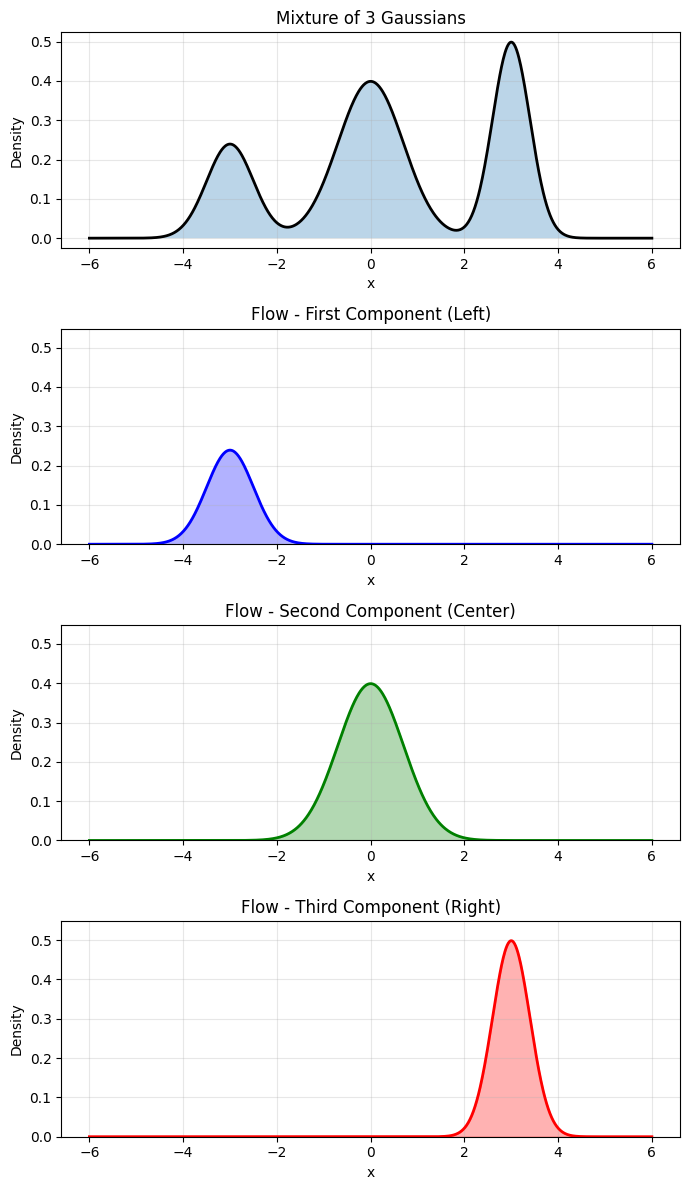

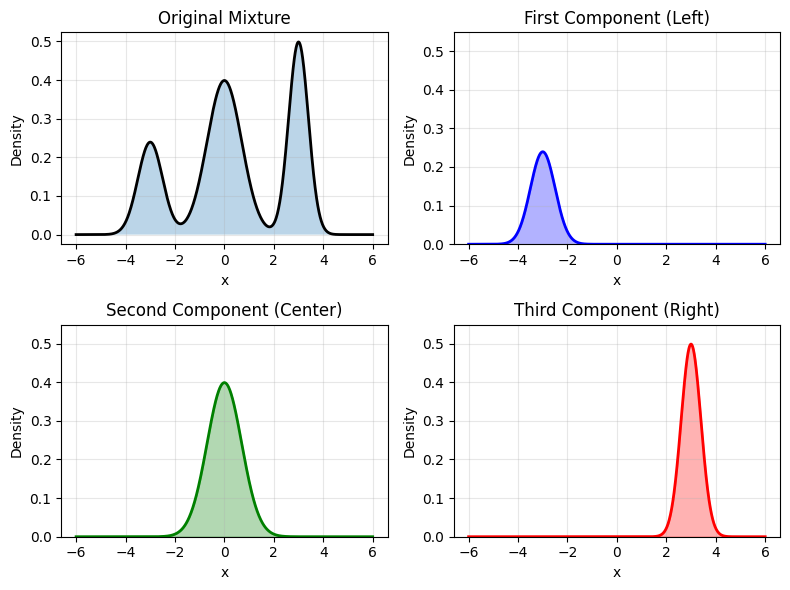

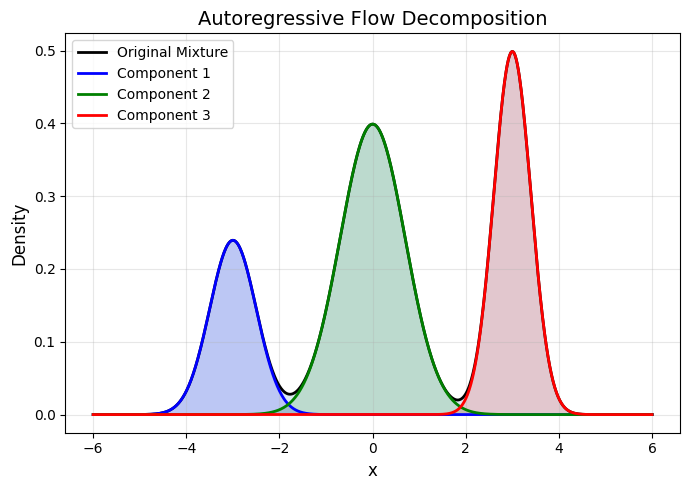

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Create figure with subplots - reduced width by adjusting figsize
fig, axes = plt.subplots(4, 1, figsize=(7, 12))

# Define parameters for 3 Gaussian components
means = [-3, 0, 3]  # Positions of the peaks
stds = [0.5, 0.7, 0.4]  # Width of each peak
weights = [0.3, 0.7, 0.5]  # Heights/weights of each peak

# Generate x values for plotting
x = np.linspace(-6, 6, 1000)

# Calculate the PDF for the mixture and each component
mixture = np.zeros_like(x)
components = []

for i in range(3):
    component = weights[i] * stats.norm.pdf(x, means[i], stds[i])
    components.append(component)
    mixture += component

# Plot the mixture distribution
axes[0].plot(x, mixture, 'k-', linewidth=2)
axes[0].fill_between(x, mixture, alpha=0.3)
axes[0].set_title('Mixture of 3 Gaussians', fontsize=12)
axes[0].set_xlabel('x', fontsize=10)
axes[0].set_ylabel('Density', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot each individual component
colors = ['blue', 'green', 'red']
titles = ['First Component (Left)', 'Second Component (Center)', 'Third Component (Right)']

for i, (component, title, color) in enumerate(zip(components, titles, colors)):
    axes[i+1].plot(x, component, color=color, linewidth=2)
    axes[i+1].fill_between(x, component, color=color, alpha=0.3)
    axes[i+1].set_title(f'Flow - {title}', fontsize=12)
    axes[i+1].set_xlabel('x', fontsize=10)
    axes[i+1].set_ylabel('Density', fontsize=10)
    axes[i+1].grid(True, alpha=0.3)
    
    # Set y-axis limit to be the same as the mixture plot for better comparison
    axes[i+1].set_ylim(0, max(mixture) * 1.1)

plt.tight_layout()
plt.savefig('autoregressive_flow_1d_compact.png', dpi=300)
plt.show()

# Create a second set of plots with components side by side for comparison
# This gives a more compact visualization for slides
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

# Plot the mixture in the first subplot
axes[0, 0].plot(x, mixture, 'k-', linewidth=2)
axes[0, 0].fill_between(x, mixture, alpha=0.3)
axes[0, 0].set_title('Original Mixture', fontsize=12)
axes[0, 0].set_xlabel('x', fontsize=10)
axes[0, 0].set_ylabel('Density', fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# Plot the components in the remaining subplots
component_positions = [(0, 1), (1, 0), (1, 1)]
for i, (component, title, color, pos) in enumerate(zip(components, titles, colors, component_positions)):
    axes[pos].plot(x, component, color=color, linewidth=2)
    axes[pos].fill_between(x, component, color=color, alpha=0.3)
    axes[pos].set_title(title, fontsize=12)
    axes[pos].set_xlabel('x', fontsize=10)
    axes[pos].set_ylabel('Density', fontsize=10)
    axes[pos].grid(True, alpha=0.3)
    axes[pos].set_ylim(0, max(mixture) * 1.1)

plt.tight_layout()
plt.savefig('autoregressive_flow_1d_grid.png', dpi=300)
plt.show()

# Generate an alternative compact visualization with all on one plot
plt.figure(figsize=(7, 5))

# Plot the mixture
plt.plot(x, mixture, 'k-', linewidth=2, label='Original Mixture')
plt.fill_between(x, mixture, alpha=0.15)

# Plot each component with transparency
for i, (component, color) in enumerate(zip(components, colors)):
    plt.plot(x, component, color=color, linewidth=2, label=f'Component {i+1}')
    plt.fill_between(x, component, color=color, alpha=0.15)

plt.title('Autoregressive Flow Decomposition', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('autoregressive_flow_1d_overlay.png', dpi=300)
plt.show()

In [17]:
def verify_entropy(mean, std, num_samples=100):
    # Set random seed for reproducibility
    key = jax.random.PRNGKey(9)
    
    # Base entropy of normal distribution (analytically calculated)
    base_entropy = 0.5 * (jnp.log(2 * jnp.pi * jnp.e) + 2 * jnp.log(std))
    
    # Generate samples from the normal distribution
    normal_samples = mean + std * jax.random.normal(key, (num_samples,))
    
    # Apply tanh transformation
    tanh_samples = jnp.tanh(normal_samples)
    
    # Calculate log det jacobian for each sample
    # This is log(d/dx tanh(x)) = log(1 - tanh²(x))
    log_det_jacobian = jnp.log(1 - tanh_samples**2)
    # Alternative calculation: 2 * (jnp.log(2) - normal_samples - jax.nn.softplus(-2 * normal_samples))
    
    # The correction term is the expected value of log_det_jacobian
    correction = jnp.mean(log_det_jacobian)
    
    # Corrected entropy
    corrected_entropy = base_entropy - correction
    
    # For verification, we can also estimate entropy directly from tanh samples
    # (Not needed for the calculation, just for verification)
    # This requires kernel density estimation or other methods
    
    return {
        "mean": mean,
        "std": std,
        "base_entropy": float(base_entropy),
        "correction": float(correction),
        "corrected_entropy": float(corrected_entropy),
        "sample_normal_range": (float(jnp.min(normal_samples)), float(jnp.max(normal_samples))),
        "sample_tanh_range": (float(jnp.min(tanh_samples)), float(jnp.max(tanh_samples)))
    }
    
verify_entropy_results = verify_entropy(mean=0, std=1.0)
print("results 1:", verify_entropy_results)
verify_entropy_results = verify_entropy(mean=0, std=0.1)
print("results 0.1:", verify_entropy_results)

results 1: {'mean': 0, 'std': 1.0, 'base_entropy': 1.4189385175704956, 'correction': -0.7506220936775208, 'corrected_entropy': 2.169560670852661, 'sample_normal_range': (-2.970475673675537, 2.200103998184204), 'sample_tanh_range': (-0.9947547912597656, 0.9757480621337891)}
results 0.1: {'mean': 0, 'std': 0.1, 'base_entropy': -0.8836466073989868, 'correction': -0.009921428747475147, 'corrected_entropy': -0.873725175857544, 'sample_normal_range': (-0.29704758524894714, 0.2200103998184204), 'sample_tanh_range': (-0.2886084020137787, 0.21652795374393463)}
